# Figure 1
In this version schematics will be based upon BEST data set

<h1 style='color: yellow'> Pre-amble</h1>

In [1]:
# Standard Library Imports
import os
import sys
from importlib import reload
from functools import partial
from itertools import groupby, cycle

# Third-Party Library Imports
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import matplotlib.patches as patches
from typing import Optional, Tuple
import cartopy.crs as ccrs
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib import cm
from scipy.stats import ks_2samp
import matplotlib.ticker as mticker
# My imports
sys.path.append(os.path.join(os.getcwd(), 'Documents', 'time_of_emergene_drafts'))
sys.path.append(os.path.join(os.getcwd(), 'Documents', 'time_of_emergene_drafts', 'src'))

import climate_utils
import plotting_utils
import my_stats
import toe_plots
import toe_calc as toe
import toe_constants as toe_const
import open_data
from toe_constants import PVALUE_THESHOLD1, OVERLAP_THRESHOLD, SN_THRESHOLD1
# Suppress Warnings
import warnings
warnings.filterwarnings('ignore')

mkdir -p failed for path /scratch/v45/dr4292/tmp/.cache/matplotlib: [Errno 13] Permission denied: '/scratch/v45/dr4292/tmp/.cache'
Matplotlib created a temporary cache directory at /jobfs/161542480.gadi-pbs/matplotlib-kzqywpbk because there was an issue with the default path (/scratch/v45/dr4292/tmp/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
from dask.distributed import Client, wait
client = Client(threads_per_worker=1, memory_limit=None, n_workers=14)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46361,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38415,Total threads: 1
Dashboard: /proxy/42977/status,Memory: 0 B
Nanny: tcp://127.0.0.1:41147,


In [4]:
xr.set_options(display_expand_attrs=False)
xr.set_options(display_expand_data=False)

<h1 style='color: yellow'> Opening Data</h1>

In [ ]:
# best_ds = open_data.open_best()

In [5]:
# ACCESS
# model = 'access'
# experiment = 'ssp585'
# variable = 'tas'#'tas' #pr
# dataset_name = f'{model}_{experiment}'

In [9]:
# BEST
model = 'best'
variable = 'tas'#'tas' #pr
dataset_name = f'{model}'

In [12]:
CHUNK_DICT = {
    'best': {'time':-1, 'lat': 180//10, 'lon': 360//10},
    'access': {'time':-1, 'member':1, 'lat': 72//4, 'lon':-1}
}
chunks = CHUNK_DICT[model]

In [13]:
FILE_NAME = f'/g/data/w40/ab2313/time_of_emergence/{dataset_name}_{variable}.zarr'
print(FILE_NAME)
data_ds = xr.open_dataset(FILE_NAME, engine='zarr', chunks=chunks)[variable].persist()
wait(data_ds);

/g/data/w40/ab2313/time_of_emergence/best_tas.zarr


NameError: name 'xr' is not defined

In [11]:
# Build global-mean series from ACCESS and keep ensemble + ensemble-median views.
data_ds_smean_raw = climate_utils.weighted_lat_lon_mean(data_ds).compute()

In [17]:
del data_ds

In [18]:
# data_ds_smean_raw.plot(hue='member');

In [20]:
# Create a data set for the base period used as the pre-industrial climate
base_period_tuple = (1850, 1880)
data_ds_smean_raw = data_ds_smean_raw.sel(time=data_ds_smean_raw.time.dt.year >= base_period_tuple[0])

In [21]:
base_period_ds = data_ds_smean_raw.where(data_ds_smean_raw.time.dt.year.isin(np.arange(*base_period_tuple)), drop=True)
base_period_ds_ens = data_ds_smean_ens.where(data_ds_smean_ens.time.dt.year.isin(np.arange(*base_period_tuple)), drop=True)
base_period_ds

NameError: name 'data_ds_smean' is not defined

In [9]:
base_period_ds_average = base_period_ds.mean(dim='time')
base_period_ds_average

<xarray.DataArray 'temperature' ()> Size: 8B
-0.2697

In [10]:
# Reset anomalies to the base period
data_ds_smean_ens = data_ds_smean_ens - base_period_ds_ens.mean(dim='time')
data_ds_smean = data_ds_smean_ens.median(dim=ensemble_dim)
base_period_ds = data_ds_smean.where(data_ds_smean.time.dt.year.isin(np.arange(*base_period_tuple)), drop=True)
base_period_ds_ens = data_ds_smean_ens.where(data_ds_smean_ens.time.dt.year.isin(np.arange(*base_period_tuple)), drop=True)


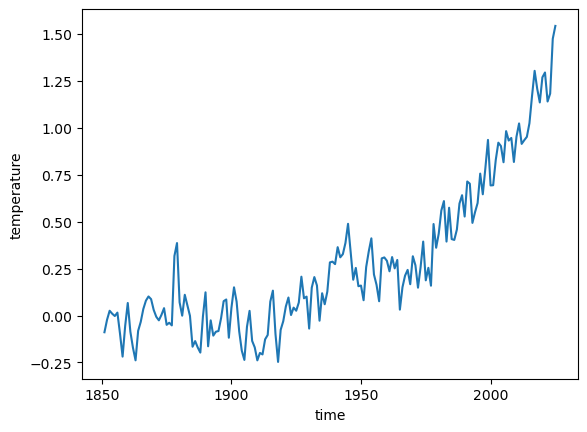

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
time_vals = data_ds_smean.time.dt.year.values

if ensemble_dim in data_ds_smean_ens.dims and data_ds_smean_ens.sizes.get(ensemble_dim, 1) > 1:
    for member_i in range(data_ds_smean_ens.sizes[ensemble_dim]):
        ax.plot(
            time_vals,
            data_ds_smean_ens.isel({ensemble_dim: member_i}).values,
            color='gray',
            alpha=0.12,
            linewidth=0.8
        )

ax.plot(time_vals, data_ds_smean.values, color='black', linewidth=2.5, label='Ensemble median')
ax.set_xlabel('Year')
ax.set_ylabel('GMST Anomaly (K)')
ax.set_title('ACCESS Ensemble Members and Ensemble Median')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left')


<h1 style='color: yellow'> Calculations</h1>

In [12]:
window = 30

<h2 style='color: cyan'> Signal-to-Noise </h2>

In [14]:
data_ds_anom_signal = data_ds_smean.copy(deep=True)

In [53]:
# Lowess
ds_data_lowess = my_stats.trend_fit(data_ds_smean, 'LOWESS', lowess_window=41)#method='POLYNOMIAL', order=4)#

# Rolling average
data_ds_rolling_20 = data_ds_smean.rolling(time=window, center=True).mean()

# Polynomial
data_ds_poly3 = xr.zeros_like(data_ds_smean)+my_stats.polynomial_fit(data_ds_smean, order=3)
data_ds_poly4 = xr.zeros_like(data_ds_smean)+my_stats.polynomial_fit(data_ds_smean, order=4)

In [59]:
data_ds_rolling_20.name = 'mean'
ds_data_lowess.name = 'lowess'
data_ds_poly4.name = 'poly'

In [79]:
ds_data_smooth = xr.merge([data_ds_rolling_20, data_ds_poly4, ds_data_lowess]) 
ds_data_smooth = ds_data_smooth.to_array('method')

In [81]:
ds_data_no_trend = data_ds_smean - ds_data_smooth
ds_data_no_trend

<xarray.DataArray (time: 175, method: 3)> Size: 4kB
nan -0.09722 -0.036 nan -0.02642 0.02787 ... nan 0.1126 0.1584 nan 0.1476 0.2027
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00
  * method   (method) object 24B 'mean' 'poly' 'lowess'

In [82]:
ds_data_noise = ds_data_no_trend.std(dim='time')

In [83]:
ds_data_sn_multi = ds_data_smooth/ds_data_noise

In [88]:
list(ds_data_sn_multi.method.values)

['mean', 'poly', 'lowess']

In [90]:
# ds_data_sn_multi = ds_data_sn_multi.rename({var: f'sn_{var}_full' for var in list(ds_data_sn_multi['method'].values)})

In [91]:
ds_data_sn_multi = ds_data_sn_multi.assign_coords(
    method=[f'sn_{var}_full' for var in ds_data_sn_multi['method'].values]
)

In [92]:
ds_data_sn_multi

<xarray.DataArray (method: 3, time: 175)> Size: 4kB
nan nan nan nan nan nan nan nan ... 11.12 11.35 11.57 11.79 12.01 12.24 12.47
Coordinates:
  * method   (method) <U14 168B 'sn_mean_full' 'sn_poly_full' 'sn_lowess_full'
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [93]:
# S/N from anomaly definition
data_ds_anom_sn = data_ds_smean / data_ds_smean.isel(time=slice(0, window)).std(dim='time')
data_ds_anom_sn.name = 'sn_anom'
data_ds_anom_sn = data_ds_anom_sn.expand_dims(dim={'method': ['sn_anom']})

# S/N based on ensemble-median signal and base-period ensemble noise
noise_dims = ['time']
if ensemble_dim in base_period_ds_ens.dims and base_period_ds_ens.sizes.get(ensemble_dim, 1) > 1:
    noise_dims = [ensemble_dim, 'time']

ens_median_noise = base_period_ds_ens.std(dim=noise_dims)
data_ds_ens_med_sn = data_ds_smean / ens_median_noise
data_ds_ens_med_sn.name = 'sn_ens_med_full'
data_ds_ens_med_sn = data_ds_ens_med_sn.expand_dims(dim={'method': ['sn_ens_med_full']})


In [94]:
ds_data_sn_multi = xr.concat([ds_data_sn_multi, data_ds_anom_sn, data_ds_ens_med_sn], dim='method')


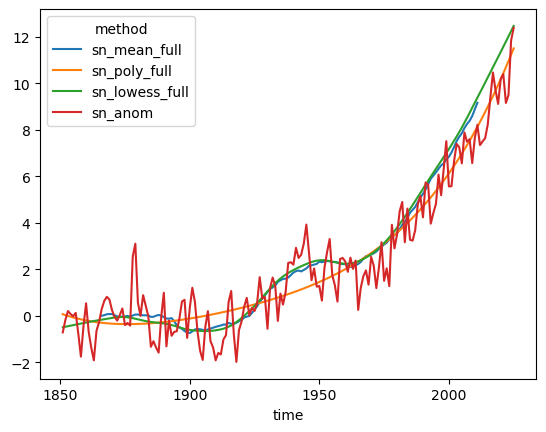

In [95]:
ds_data_sn_multi.plot(hue='method');

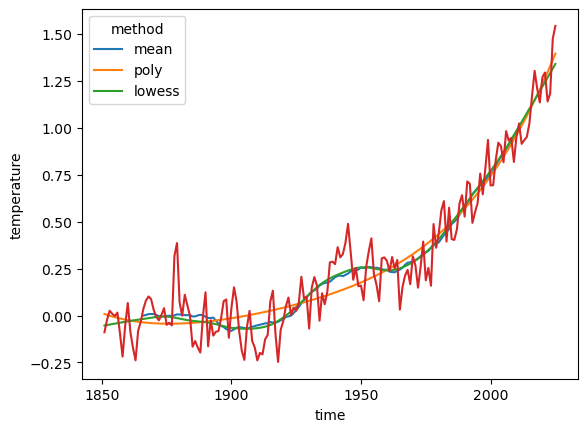

In [96]:
ds_data_smooth.plot(hue='method');
data_ds_smean.plot()

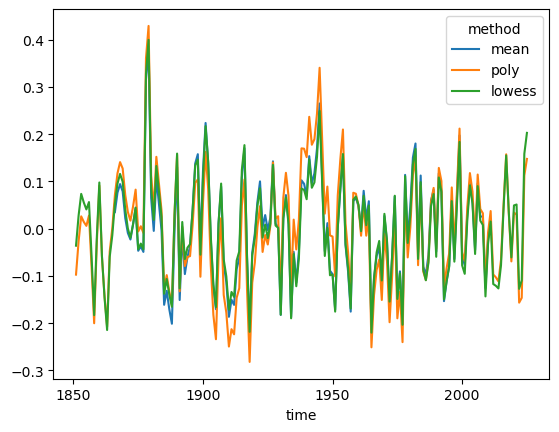

In [97]:
ds_data_no_trend.plot(hue='method');

In [101]:
# LEGACY 
# ds_data_lowess_signal = ds_data_lowess#- base_period_ds_average
# Note - you have to use loc as method is a keyword lol
# ds_data_sn = ds_data_sn_multi.loc[{'method':'sn_lowess_full'}]#ds_data_lowess_signal/noise_ds

<h2 style='color: cyan'>  p-value and overlap </h2>

In [105]:
import toe_data_analysis

In [106]:
# This version is better
ks_ds = toe.stats_test_1d_xr(
    data_ds_smean, window=window, stats_func=toe.return_ks_pvalue)

ttest_ds = toe.stats_test_1d_xr(
    data_ds_smean, window=window, stats_func=toe.return_ttest_pvalue)

In [107]:
frac_geom_func = partial(toe.fractional_geometric_area, method_kwargs=dict(bw_method=0.2))
frac_geom_ds = toe.stats_test_1d_xr(data_ds_smean, window=30, stats_func=frac_geom_func)
hd_ds = toe.stats_test_1d_xr(data_ds_smean, window=30, stats_func=toe.hellinger_distance)

In [108]:
# anderson_ds = toe.stats_test_1d_xr(
#     data_ds_smean, window=window, stats_func=toe.return_anderson_pvalue)

In [109]:
# bins = toe.calculate_freedman_diaconis_bins(data_ds_smean.values)
# bins

In [110]:
# perkins_ds = toe.stats_test_1d_xr(data_ds_smean, window=30, stats_func=partial(toe.perkins_skill_score, bins=bins));

<h2 style='color: cyan'>ToENN</h2>

In [111]:
base_max_value = base_period_ds.max().values.item()
base_max_value

0.386079803109169

In [112]:
new_normal_ds = data_ds_rolling_20 > base_max_value
new_normal_ds

<xarray.DataArray 'mean' (time: 175)> Size: 175B
False False False False False False ... False False False False False False
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [ ]:
# Probability Ratio (PR): event = GMST anomaly above base-period quantile
pr_event_quantile = 0.95
pr_window = 30

base_slice_ens = data_ds_smean_ens.sel(time=slice(str(base_period_tuple[0]), str(base_period_tuple[1])))
q_dims = ['time'] + ([ensemble_dim] if ensemble_dim in base_slice_ens.dims else [])
pr_threshold = float(base_slice_ens.quantile(pr_event_quantile, dim=q_dims).values.item())

pr_event_da = xr.where(data_ds_smean_ens > pr_threshold, 1.0, 0.0)
p0 = float(pr_event_da.sel(time=slice(str(base_period_tuple[0]), str(base_period_tuple[1]))).mean(dim=q_dims).values.item())
p0_safe = max(p0, 1e-6)

p1 = pr_event_da.rolling(time=pr_window, center=True).mean()
if ensemble_dim in p1.dims:
    p1 = p1.mean(dim=ensemble_dim)

pr_ds = (p1 / p0_safe).rename('pr')
pr_ds


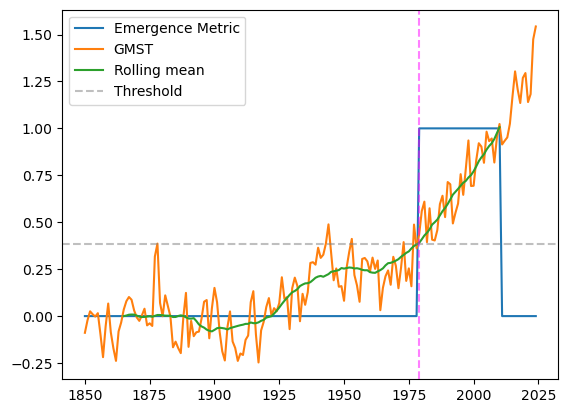

In [113]:
fig, ax = plt.subplots(1, 1)
ax.plot(new_normal_ds.time.dt.year.values, new_normal_ds.values, label='Emergence Metric')
ax.plot(new_normal_ds.time.dt.year.values,data_ds_smean.values, label='GMST')
ax.plot(new_normal_ds.time.dt.year.values, data_ds_rolling_20.values, label='Rolling mean')
ax.axhline(base_max_value, linestyle='--', color='grey', alpha=0.5, label='Threshold')
ax.axvline(1979, linestyle='--', color='magenta', alpha=0.5)
ax.legend()


<h2 style='color: cyan'> ToE </h2>

In [114]:
# ds_data_sn_multi.loc[{'method':'sn_lowess_full'}]name = 'sn'
ks_ds.name = 'ks'
ttest_ds.name = 'ttest'
# anderson_ds.name = 'anderson'
# perkins_ds.name = 'perkins'
frac_geom_ds.name = 'frac'
hd_ds.name = 'hd'
new_normal_ds.name = 'nn'

In [115]:
# Set long name attributes for each variable
# ds_data_sn_multi.loc[{'method':'sn_lowess_full'}]attrs['long_name'] = 'Signal to Noise Ratio'
ks_ds.attrs['long_name'] = 'Kolmogorov-Smirnov'
ttest_ds.attrs['long_name'] = 'T-Test'
# anderson_ds.attrs['long_name'] = 'Anderson-Darling'
# perkins_ds.attrs['long_name'] = 'Perkins Skill Score'
frac_geom_ds.attrs['long_name'] = 'Area of Overlap'
hd_ds.attrs['long_name'] = 'Hellinger Distance'
new_normal_ds.attrs['long_name']  = 'New Normal'

In [116]:
ds_data_sn_multi

<xarray.DataArray (method: 4, time: 175)> Size: 6kB
nan nan nan nan nan nan nan nan ... 9.112 10.19 10.39 9.152 9.492 11.83 12.38
Coordinates:
  * method   (method) object 32B 'sn_mean_full' 'sn_poly_full' ... 'sn_anom'
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [117]:
# toe_metrics_ds = xr.merge([ks_ds, ttest_ds, anderson_ds, ds_data_sn, perkins_ds, frac_geom_ds])
metric_arrays = [
    ks_ds,
    ttest_ds,
    ds_data_sn_multi.to_dataset(dim='method'),
    frac_geom_ds,
    hd_ds,
    new_normal_ds
]

if 'pr_ds' in globals():
    metric_arrays.append(pr_ds)

toe_metrics_ds = xr.merge(metric_arrays)
toe_metrics_ds = toe_metrics_ds.isel(time=slice(None, -int(window/2)))
toe_metrics_ds = toe_metrics_ds.compute()
toe_metrics_ds


<xarray.Dataset> Size: 12kB
Dimensions:         (time: 160)
Coordinates:
  * time            (time) object 1kB 1850-12-31 00:00:00 ... 2009-12-31 00:0...
Data variables:
    ks              (time) float64 1kB nan nan nan ... 2.254e-22 2.254e-22
    ttest           (time) float64 1kB nan nan nan ... 7.049e-41 4.489e-41
    sn_mean_full    (time) float64 1kB nan nan nan nan ... 8.384 8.593 8.873
    sn_poly_full    (time) float64 1kB 0.06798 0.03047 -0.004974 ... 7.724 7.923
    sn_lowess_full  (time) float64 1kB -0.4927 -0.4706 -0.4482 ... 8.944 9.161
    sn_anom         (time) float64 1kB -0.7142 -0.1824 0.2046 ... 6.567 7.648
    frac            (time) float64 1kB nan nan nan ... 0.291 0.02973 0.003464
    hd              (time) float64 1kB nan nan nan nan ... 97.94 98.71 99.08
    nn              (time) bool 160B False False False False ... True True True
Attributes: (1)

In [118]:
print(f'{OVERLAP_THRESHOLD=}, {PVALUE_THESHOLD1=}')

OVERLAP_THRESHOLD=62, PVALUE_THESHOLD1=0.01


In [122]:
toe_metrics_ds

<xarray.Dataset> Size: 12kB
Dimensions:         (time: 160)
Coordinates:
  * time            (time) object 1kB 1850-12-31 00:00:00 ... 2009-12-31 00:0...
Data variables:
    ks              (time) float64 1kB nan nan nan ... 2.254e-22 2.254e-22
    ttest           (time) float64 1kB nan nan nan ... 7.049e-41 4.489e-41
    sn_mean_full    (time) float64 1kB nan nan nan nan ... 8.384 8.593 8.873
    sn_poly_full    (time) float64 1kB 0.06798 0.03047 -0.004974 ... 7.724 7.923
    sn_lowess_full  (time) float64 1kB -0.4927 -0.4706 -0.4482 ... 8.944 9.161
    sn_anom         (time) float64 1kB -0.7142 -0.1824 0.2046 ... 6.567 7.648
    frac            (time) float64 1kB nan nan nan ... 0.291 0.02973 0.003464
    hd              (time) float64 1kB nan nan nan nan ... 97.94 98.71 99.08
    nn              (time) bool 160B False False False False ... True True True
Attributes: (1)

In [124]:
# Find year of permanent exceedance
sn_vars = [var for var in toe_metrics_ds.data_vars if var.startswith('sn_')]
sn_toe_ds = toe.get_permanent_exceedance(
    np.abs(toe_metrics_ds[sn_vars]),
    threshold=1,
    comparison_func=np.greater_equal
)

# None can be used if the values are already bool
nn_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['nn'], threshold=None, comparison_func=None)

ks_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['ks'], threshold=PVALUE_THESHOLD1, comparison_func=np.less)
ttest_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['ttest'], threshold=PVALUE_THESHOLD1, comparison_func=np.less)
frac_geom_toe_ds = toe.get_permanent_exceedance(frac_geom_ds, threshold=OVERLAP_THRESHOLD, comparison_func=np.less_equal)
hd_toe_ds = toe.get_permanent_exceedance(hd_ds, threshold=OVERLAP_THRESHOLD, comparison_func=np.greater_equal)

toe_items = [sn_toe_ds, ks_toe_ds, ttest_toe_ds, frac_geom_toe_ds, hd_toe_ds, nn_toe_ds]
if 'pr' in toe_metrics_ds.data_vars:
    pr_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['pr'], threshold=2.0, comparison_func=np.greater_equal)
    toe_items.append(pr_toe_ds)

toe_ds = xr.merge(toe_items)

# Keep emergence years inside the available data period
max_year = int(data_ds_smean.time.dt.year.max())
toe_ds = xr.where(toe_ds <= max_year, toe_ds, np.nan)


In [125]:
# anderson_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['anderson'], threshold=PVALUE_THESHOLD1, comparison_func=np.less)
# sn_toe_ds = toe.get_permanent_exceedance(np.abs(toe_metrics_ds['sn']), threshold=1, comparison_func=np.greater_equal)
# perkins_toe_ds = toe.get_permanent_exceedance(perkins_ds, threshold=OVERLAP_THRESHOLD, comparison_func=np.less_equal)

In [126]:
toe_ds.to_pandas()

sn_poly_full      1939.0
sn_lowess_full    1929.0
sn_mean_full      1929.0
sn_anom           1965.0
ks                1926.0
ttest             1926.0
frac              1928.0
hd                1945.0
nn                1979.0
dtype: float64

<h1 style='color: yellow'> Plotting</h1> 

<h2 style='color: cyan'> GMST Plot</h2>

In [142]:
reload(toe_plots)
apply_toe_plot_styles()


<module 'toe_plots' from '/home/563/ab2313/Documents/time_of_emergene_drafts/src/toe_plots.py'>

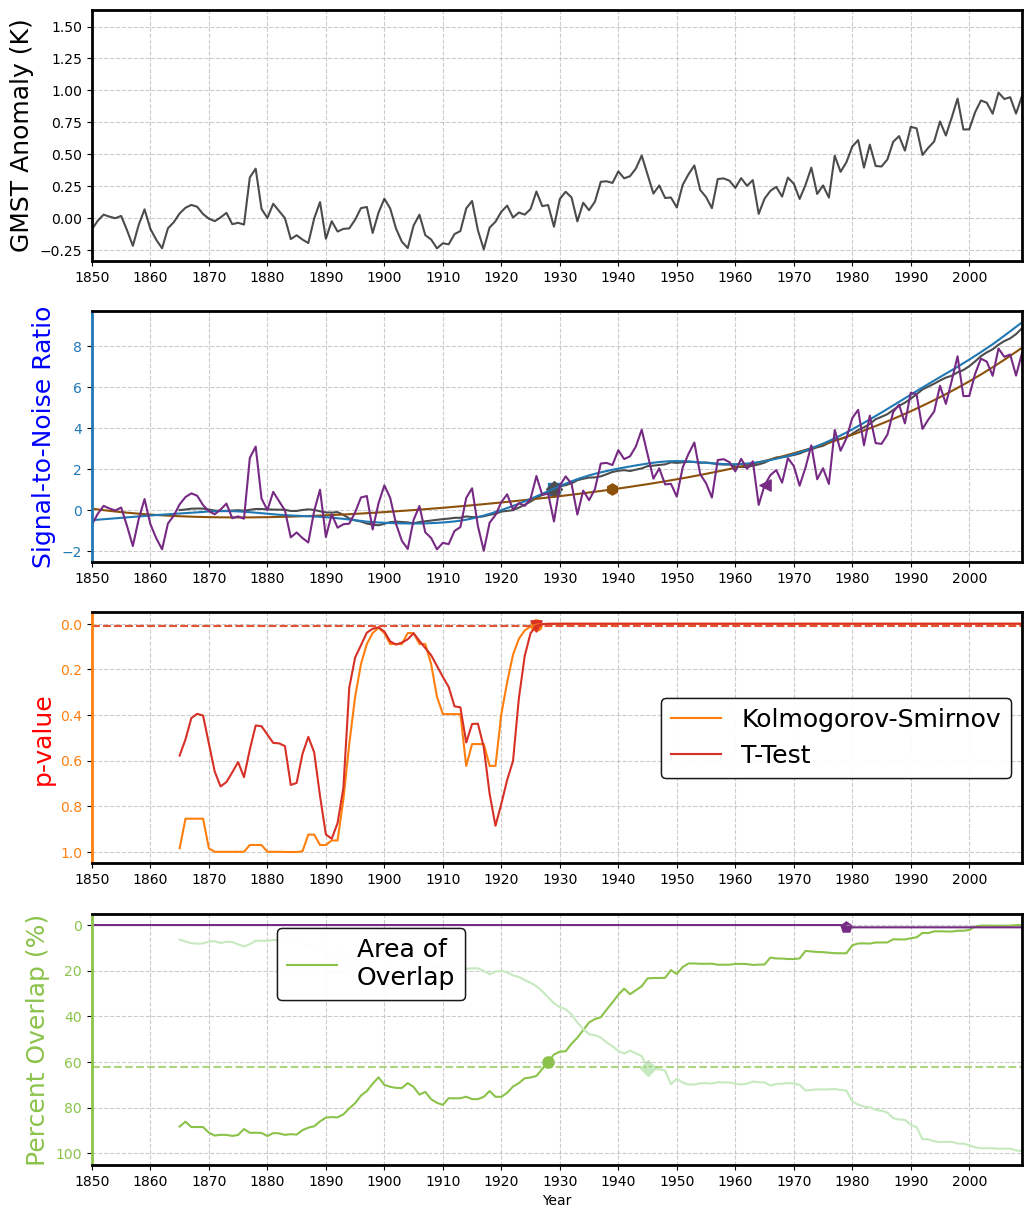

In [143]:
fig, gs, axes = plot_toe_panel(
    toe_metrics_ds,
    toe_ds,
    data_ds_smean
)


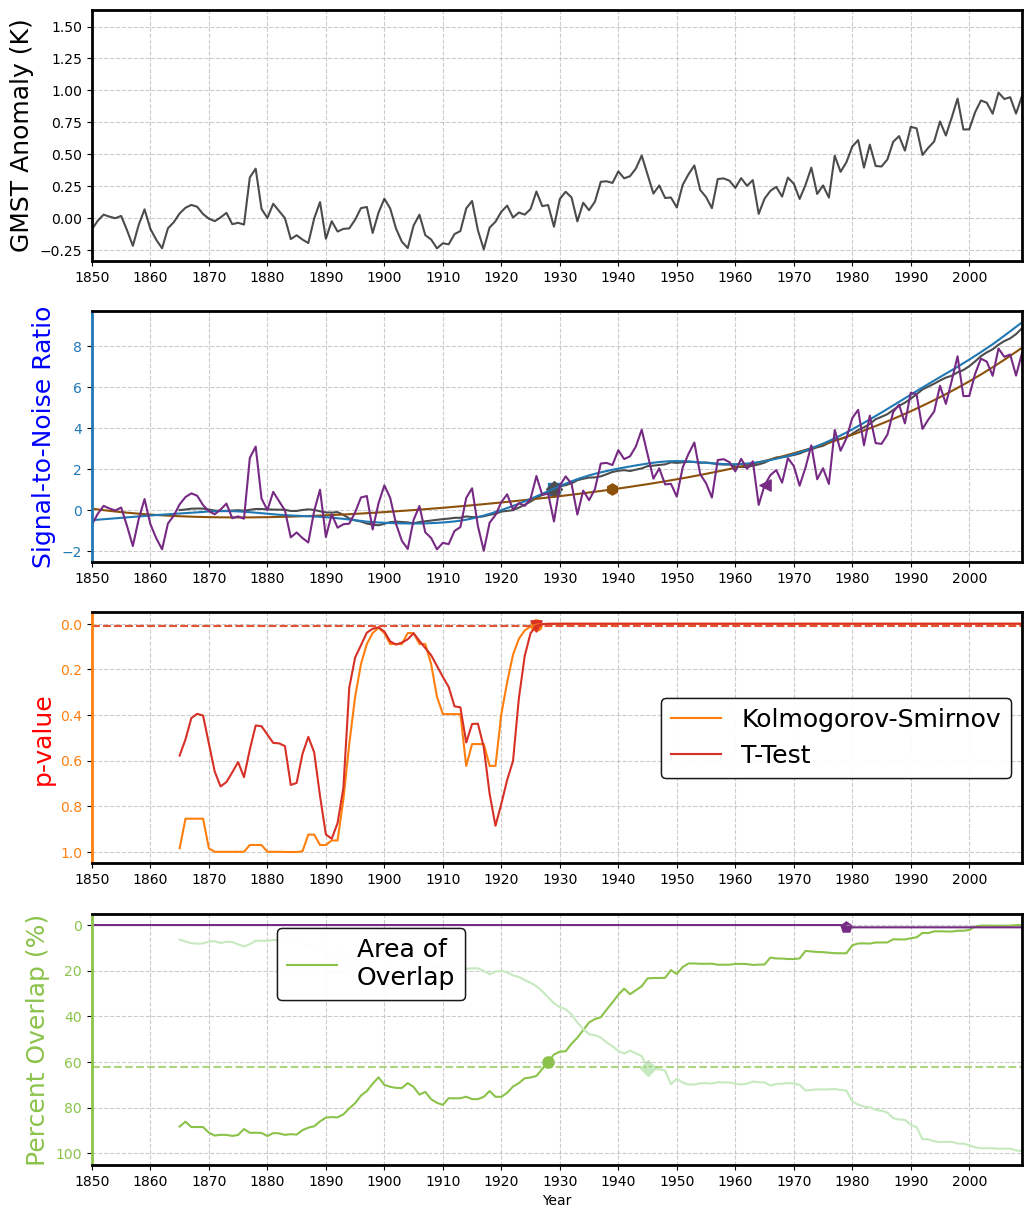

In [144]:
fig, gs, axes = plot_toe_panel(
    toe_metrics_ds,
    toe_ds,
    data_ds_smean,
    draw_toe_lines=True
)


In [150]:
test_subset = ['ks', 'sn_lowess_full', 'frac']

In [151]:
toe_ds[test_subset].to_array().values

array([1926., 1929., 1928.])

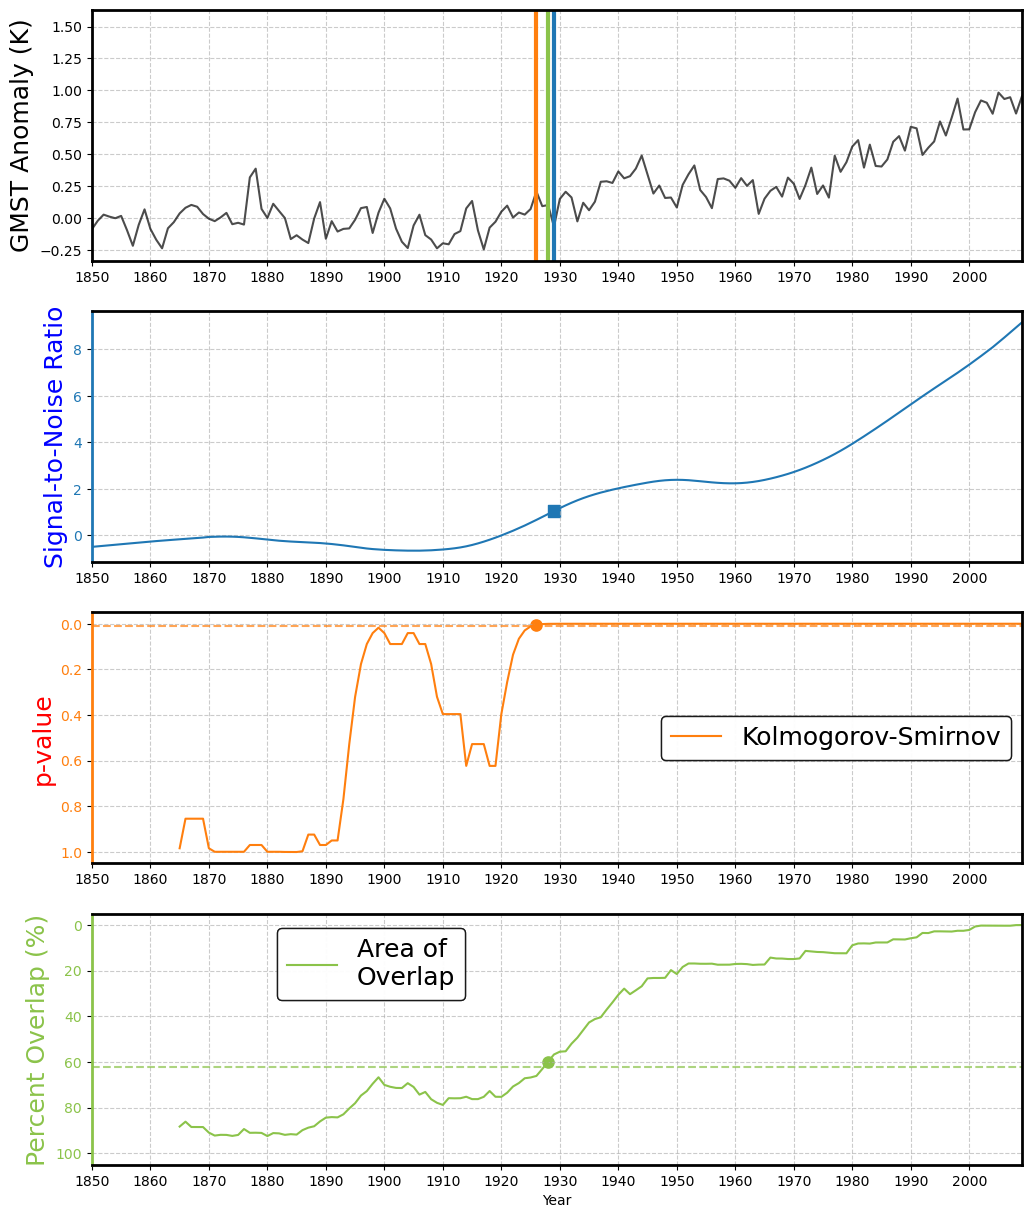

In [152]:
reload(toe_plots)
fig, gs, axes = plot_toe_panel(
    toe_metrics_ds,
    toe_ds,
    data_ds_smean,
    test_subset=test_subset,
    draw_toe_lines=True
)


<h2 style='color: cyan'> S/N Ratio</h2>

In [153]:
central_year  = 1940
period_of_interest_ds = data_ds_smean.sel(time=data_ds_smean.time.dt.year.isin(np.arange(central_year-20, central_year+21)))

In [154]:
bins = np.arange(-0.5, 0.6, .03)

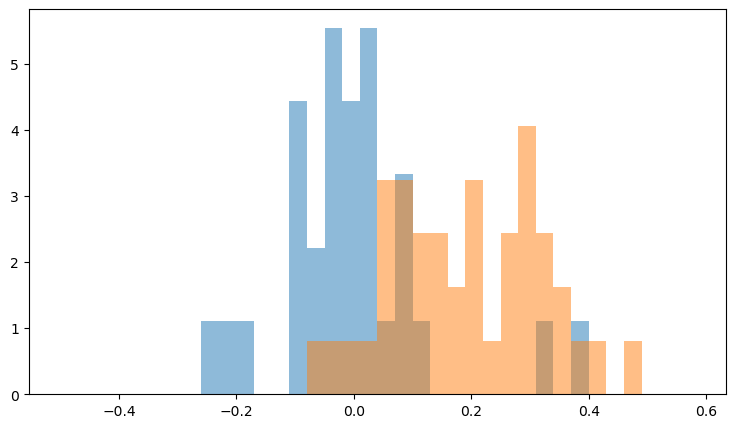

In [155]:
fig, ax  = plt.subplots(figsize=(9, 5))


# base_period_ds.plot(ax=ax)
# period_of_interest_ds.plot(ax=ax)
ax.hist(base_period_ds.values, bins=bins, density=True, alpha=0.5, label='base perdiod');
ax.hist(period_of_interest_ds.values, bins=bins, density=True, alpha=0.5, label='period of interest');
# ax.legend(ncol=1)

# axes_bottom[1].hist(base_period_ds.values, cumulative=True, alpha=0.5);
# axes_bottom[1].hist(period_of_interest_ds.values, cumulative=True, alpha=0.5);

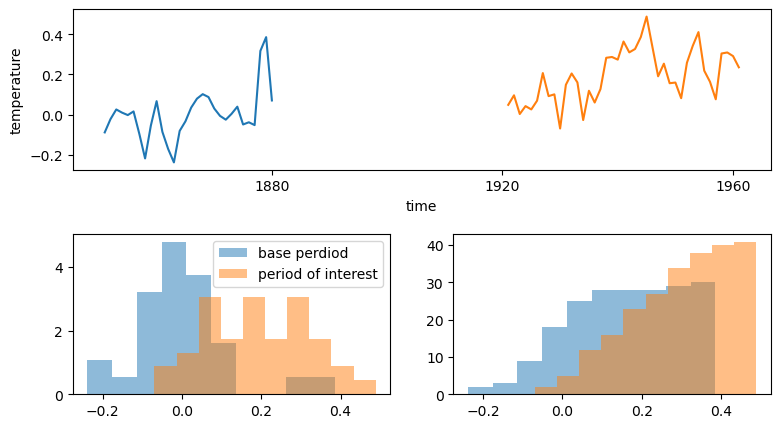

In [156]:
fig  = plt.figure(figsize=(9, 5))
gs = gridspec.GridSpec(2, 2, hspace=0.4)
ax_top = fig.add_subplot(gs[0, :])
axes_bottom = [fig.add_subplot(gs[1, i]) for i in [0, 1]]

base_period_ds.plot(ax=ax_top)
period_of_interest_ds.plot(ax=ax_top)
axes_bottom[0].hist(base_period_ds.values, density=True, alpha=0.5, label='base perdiod');
axes_bottom[0].hist(period_of_interest_ds.values, density=True, alpha=0.5, label='period of interest');
axes_bottom[0].legend(ncol=1)

axes_bottom[1].hist(base_period_ds.values, cumulative=True, alpha=0.5);
axes_bottom[1].hist(period_of_interest_ds.values, cumulative=True, alpha=0.5);

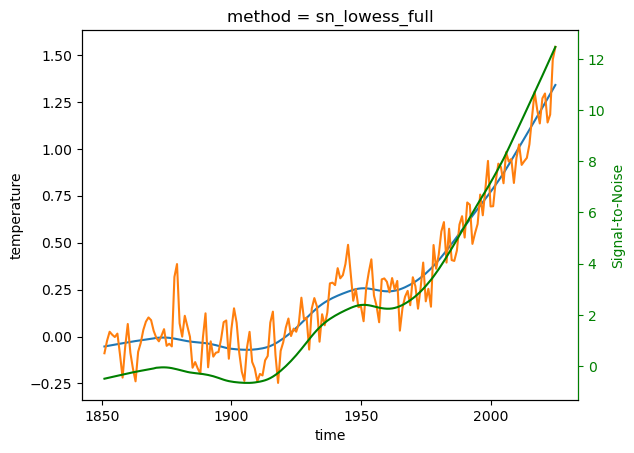

In [160]:
fig, ax = plt.subplots()
ax_twinx = ax.twinx()
ds_data_lowess.plot(ax=ax)
data_ds_smean.plot(ax=ax)
ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].plot(ax=ax_twinx, color='green')

ax_twinx.set_ylabel('Signal-to-Noise', color='green')
ax_twinx.tick_params(axis='y', color='green', labelcolor='green')
ax_twinx.spines['right'].set_color('green')

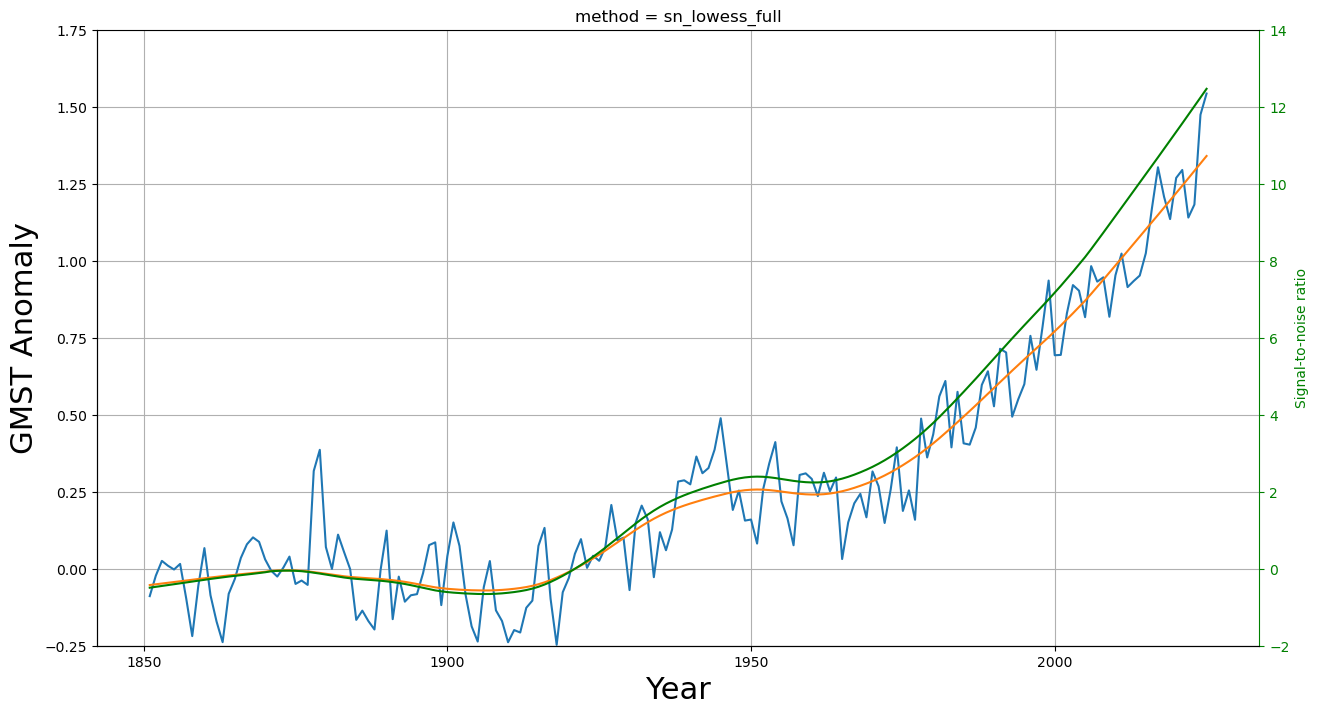

In [162]:
fig, ax = plt.subplots(figsize=(15, 8))
data_ds_smean.plot(ax=ax)
ds_data_lowess.plot(ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('GMST Anomaly', fontsize=22)
ax.set_xlabel('Year', fontsize=22)

ax_twinx = ax.twinx()


ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].plot(ax=ax_twinx, color='green')

ax_twinx.set_ylabel('Signal-to-noise ratio', color='green')
ax_twinx.tick_params(axis='y', color='green', labelcolor='green')
ax_twinx.spines['right'].set_color('green')

ax.set_ylim(-0.25, 1.75)
ax1 = ax
ax2 = ax_twinx
ax2.set_ylim(-2,14)
ax1.set_yticks(np.linspace(ax1.get_ybound()[0], ax1.get_ybound()[1], 9))
ax2.set_yticks(np.linspace(ax2.get_ybound()[0], ax2.get_ybound()[1], 9))

ax.grid(True)


In [163]:
data_ds_smean.time[data_ds_smean.time.dt.year == 1935].values

array([cftime.DatetimeGregorian(1935, 12, 31, 0, 0, 0, 0, has_year_zero=False)],
      dtype=object)

<xarray.DataArray (method: 4, time: 1)> Size: 32B
1.586 0.8568 1.692 0.482
Coordinates:
  * method   (method) object 32B 'sn_mean_full' 'sn_poly_full' ... 'sn_anom'
  * time     (time) object 8B 1935-12-31 00:00:00

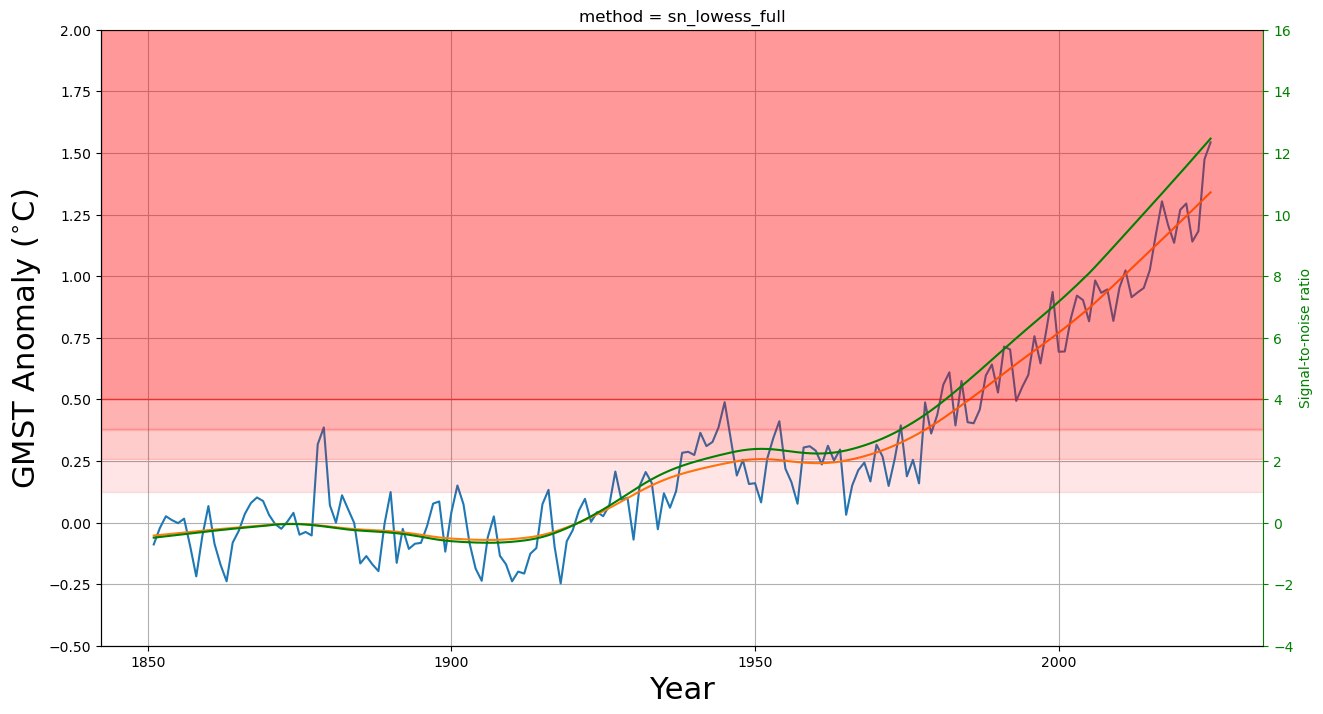

In [184]:
fig, ax = plt.subplots(figsize=(15, 8))

data_ds_smean.plot(ax=ax)
ds_data_lowess.plot(ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('GMST Anomaly ($^{\circ}$C)', fontsize=22)  # Corrected axis label
ax.set_xlabel('Year', fontsize=22)

ax_twinx = ax.twinx()

ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].plot(ax=ax_twinx, color='green')

ax_twinx.set_ylabel('Signal-to-noise ratio', color='green')
ax_twinx.tick_params(axis='y', color='green', labelcolor='green')
ax_twinx.spines['right'].set_color('green')

ax.set_ylim(-0.5, 2)

ax1 = ax
ax2 = ax_twinx
# ax2.set_ylim(-2,14)
ax2.set_ylim(-4,16)

ax1.set_yticks(np.linspace(ax1.get_ybound()[0], ax1.get_ybound()[1], 11))
ax2.set_yticks(np.linspace(ax2.get_ybound()[0], ax2.get_ybound()[1], 11))

ax2.axhspan(1, 2, color='red', alpha=0.1)
ax2.axhspan(2.05, 3, color='red', alpha=0.2)
ax2.axhspan(3.05, 4, color='red', alpha=0.3)
ax2.axhspan(4., 16, color='red', alpha=0.4)

ax.grid(True)

# sn_lowess = ds_data_sn_multi.sel(method='sn_lowess_full')#.sel(time='1935').squeeze()

# ax2.scatter(sn_lowess.time.values, sn_lowess.values,
#             s=120, color='red', zorder=1000)

# ax2.scatter(ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].time[ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].time.dt.year == 1935].values[0], ds_data_sn[ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].time.dt.year == 1935].values[0], 
#            s=120, color='red', zorder=1000)

# ax.set_xlim(*np.take(ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].time.values,[0, -1]))

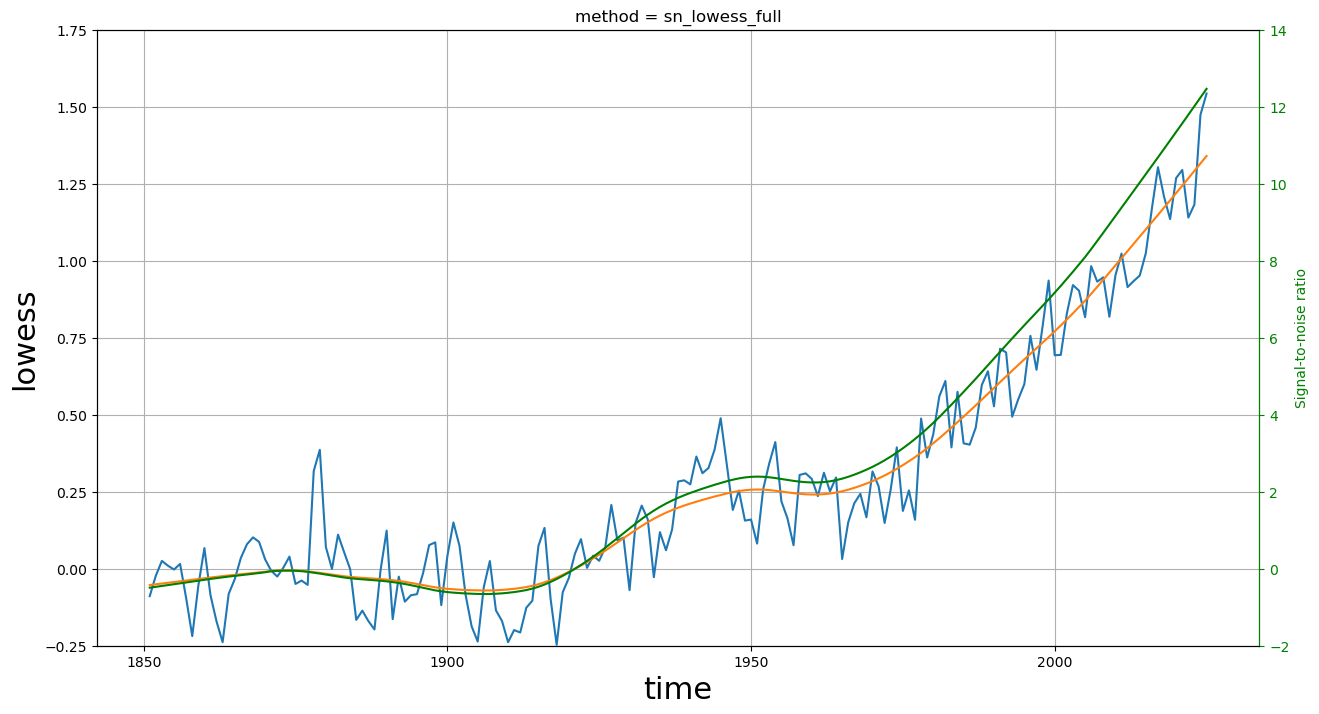

In [185]:
fig, ax = plt.subplots(figsize=(15, 8))
ax_twinx = ax.twinx()


# Define the rectangular patches on the secondary y-axis
xstart = ax_twinx.get_xbound()[0]
width = np.sum(np.abs(ax_twinx.get_xbound()))

rect1 = patches.Rectangle((xstart, -2), width, 3, edgecolor=None, alpha=0.4, facecolor='grey', zorder=1)
rect2 = patches.Rectangle((xstart, 1), width, 1, edgecolor=None, alpha=0.6, facecolor='grey', zorder=1)
rect3 = patches.Rectangle((xstart, 2), width, 1, edgecolor=None, alpha=0.8, facecolor='grey', zorder=1)
rect4 = patches.Rectangle((xstart, 3), width, 1, edgecolor=None, alpha=1, facecolor='grey', zorder=1)

# Add patches to the secondary y-axis
ax_twinx.add_patch(rect1)
ax_twinx.add_patch(rect2)
ax_twinx.add_patch(rect3)
ax_twinx.add_patch(rect4)

# Plot on the secondary y-axis
ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].plot(ax=ax_twinx, color='green', zorder=2)  # Ensure the plot is in front

# Labels and grid
ax.set_ylabel('GMST Anomaly', fontsize=22)
ax.set_xlabel('Year', fontsize=22)
ax_twinx.set_ylabel('Signal-to-noise ratio', color='green')
ax_twinx.tick_params(axis='y', colors='green', labelcolor='green')
ax_twinx.spines['right'].set_color('green')

ax.set_ylim(-0.25, 1.75)
ax_twinx.set_ylim(-2, 14)
ax.set_yticks(np.linspace(ax.get_ybound()[0], ax.get_ybound()[1], 9))
ax_twinx.set_yticks(np.linspace(ax_twinx.get_ybound()[0], ax_twinx.get_ybound()[1], 9))


# Plot on the primary y-axis
data_ds_smean.plot(ax=ax, zorder=3)  # Ensure these plots are in front
ds_data_lowess.plot(ax=ax, zorder=3)  # Ensure these plots are in front

ax.grid(True)



Text(1861, 5, 'Inconceivable')

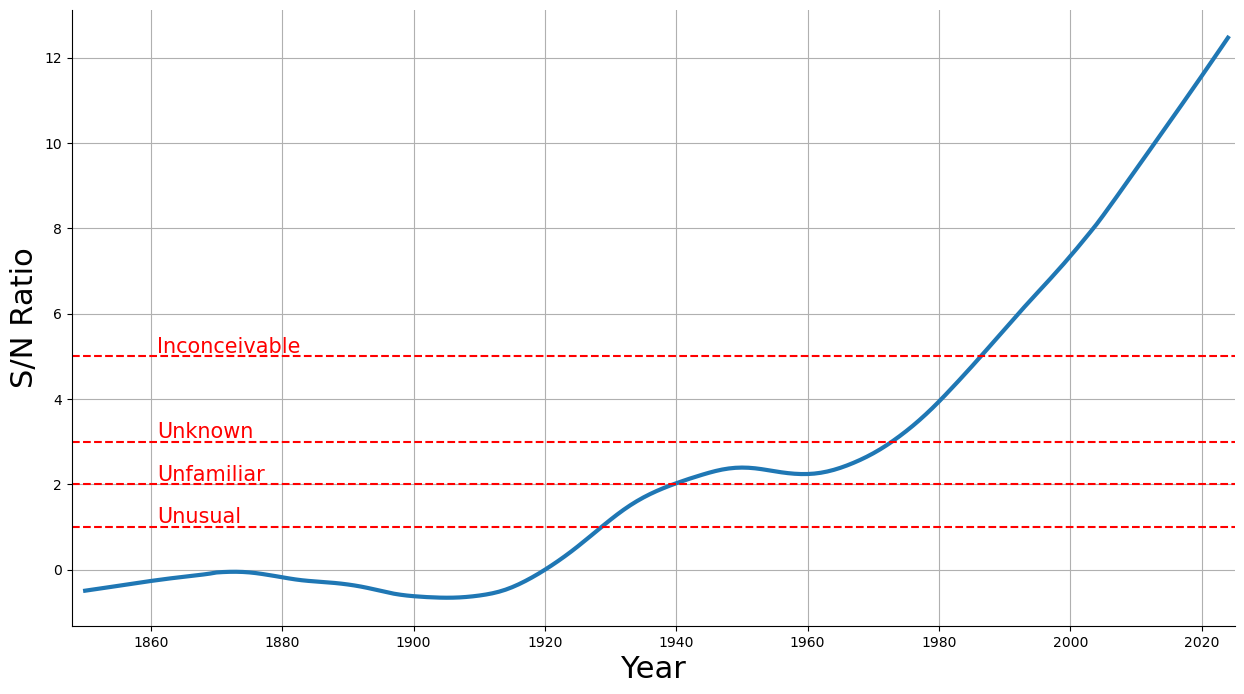

In [187]:
fig, ax = plt.subplots(figsize=(15, 8))
time = ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].time.dt.year.values
ax.plot(time, ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].values, linewidth=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('S/N Ratio', fontsize=22)
ax.set_xlabel('Year', fontsize=22)
ax.grid(True)


ax.set_xlim(1848, 2025)


frame_lines = dict(linestyle='--', color='red')
ax.axhline(1, **frame_lines)
ax.annotate('Unusual', xy=(1861, 1), va='bottom', size=15, color='red')
ax.axhline(2, **frame_lines)
ax.annotate('Unfamiliar', xy=(1861, 2), va='bottom', size=15, color='red')
ax.axhline(3, **frame_lines)
ax.annotate('Unknown', xy=(1861, 3), va='bottom', size=15, color='red')

ax.axhline(5, **frame_lines)
ax.annotate('Inconceivable', xy=(1861, 5), va='bottom', size=15, color='red')


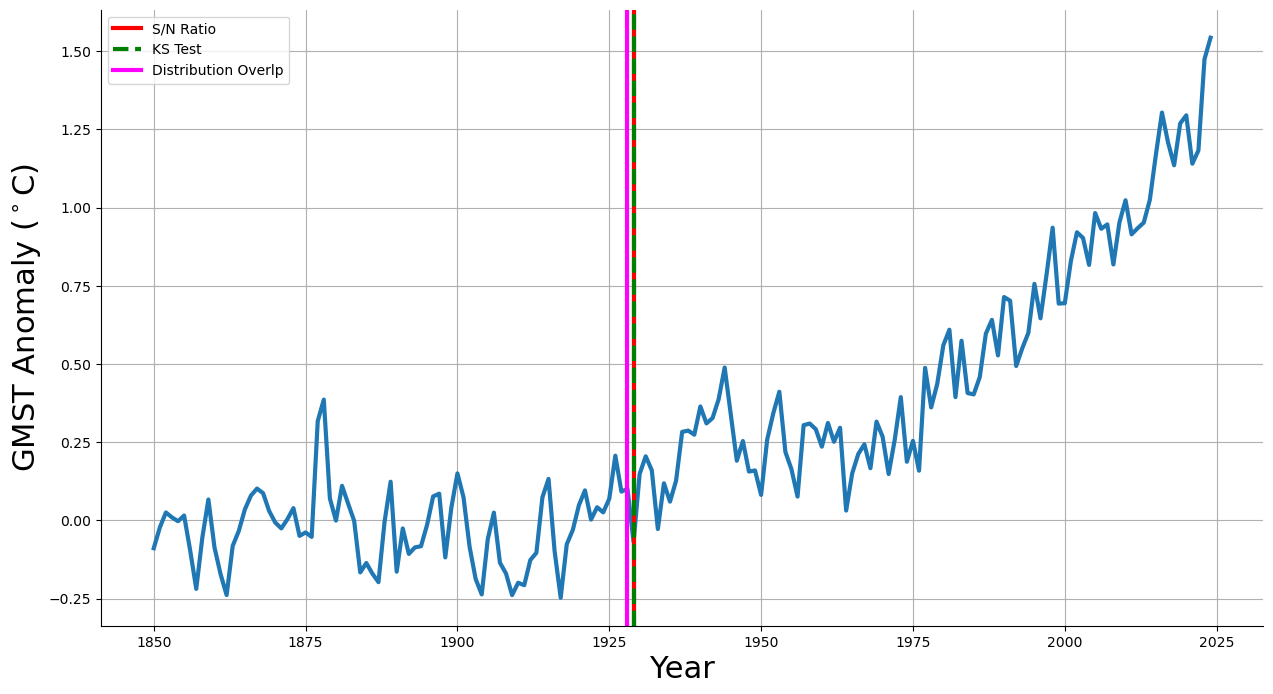

In [188]:
fig, ax = plt.subplots(figsize=(15, 8))
time = ds_data_lowess.time.dt.year.values
ax.plot(time, data_ds_smean.values, linewidth=3)
# ax.plot(time, ds_data_lowess.values, linewidth=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('GMST Anomaly'+ r' ($^\circ$C)', fontsize=22)
ax.set_xlabel('Year', fontsize=22)
ax.grid(True)

ax.axvline(1929, linewidth=3, color='red', label='S/N Ratio')
ax.axvline(1929, linewidth=3, color='green', linestyle='--', label='KS Test')
ax.axvline(1928, linewidth=3, color='magenta', label='Distribution Overlp')
ax.legend()

(1848.0, 2025.0)

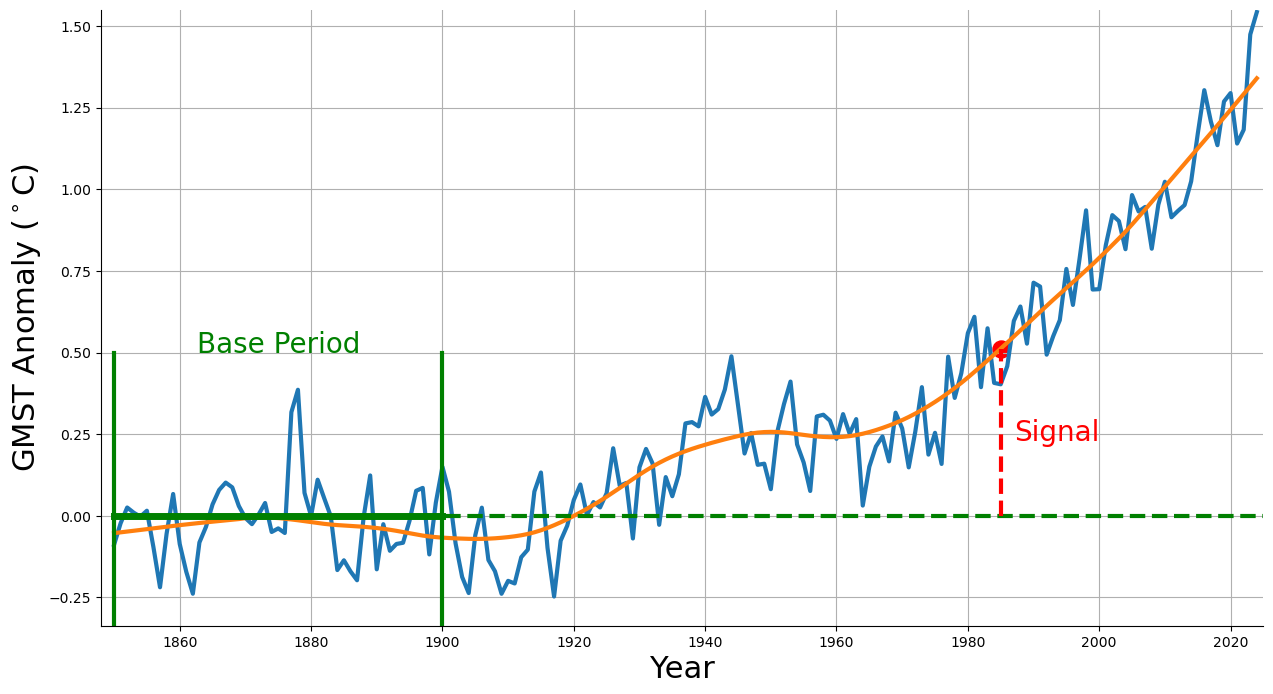

In [189]:
fig, ax = plt.subplots(figsize=(15, 8))
time = ds_data_lowess.time.dt.year.values
ax.plot(time, data_ds_smean.values, linewidth=3)
ax.plot(time, ds_data_lowess.values, linewidth=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('GMST Anomaly' + r' ($^\circ$C)', fontsize=22)
ax.set_xlabel('Year', fontsize=22)
ax.grid(True)

ylower = ax.get_ylim()[0]
ax.plot([1850, 1850], [ylower, 0.5], linewidth=3, color='green')
ax.plot([1900, 1900], [ylower, 0.5], linewidth=3, color='green')
ax.plot([1850, 2025], [0, 0], color='green', linewidth=3, linestyle='--')
ax.plot([1850, 1900], [0, 0], color='green', linewidth=5)

itime = 135
ax.scatter(time[itime], ds_data_lowess.values[itime], marker='o', s=150,
          color='red')
ax.plot([time[itime], time[itime]], [0, ds_data_lowess.values[itime]],
       color='red', linewidth=3, linestyle='--')

ax.annotate('Signal', xy=(time[itime]+2, ds_data_lowess.values[itime]/2), fontsize=20, ha='left', 
            color='red', va='center')

ax.set_ylim(ylower, 1.55)
ax.annotate('Base Period', xy=(1875, 0.5), fontsize=20, ha='center', color='green')

ax.set_xlim(1848, 2025)

Text(1861, 5, 'Inconceivable')

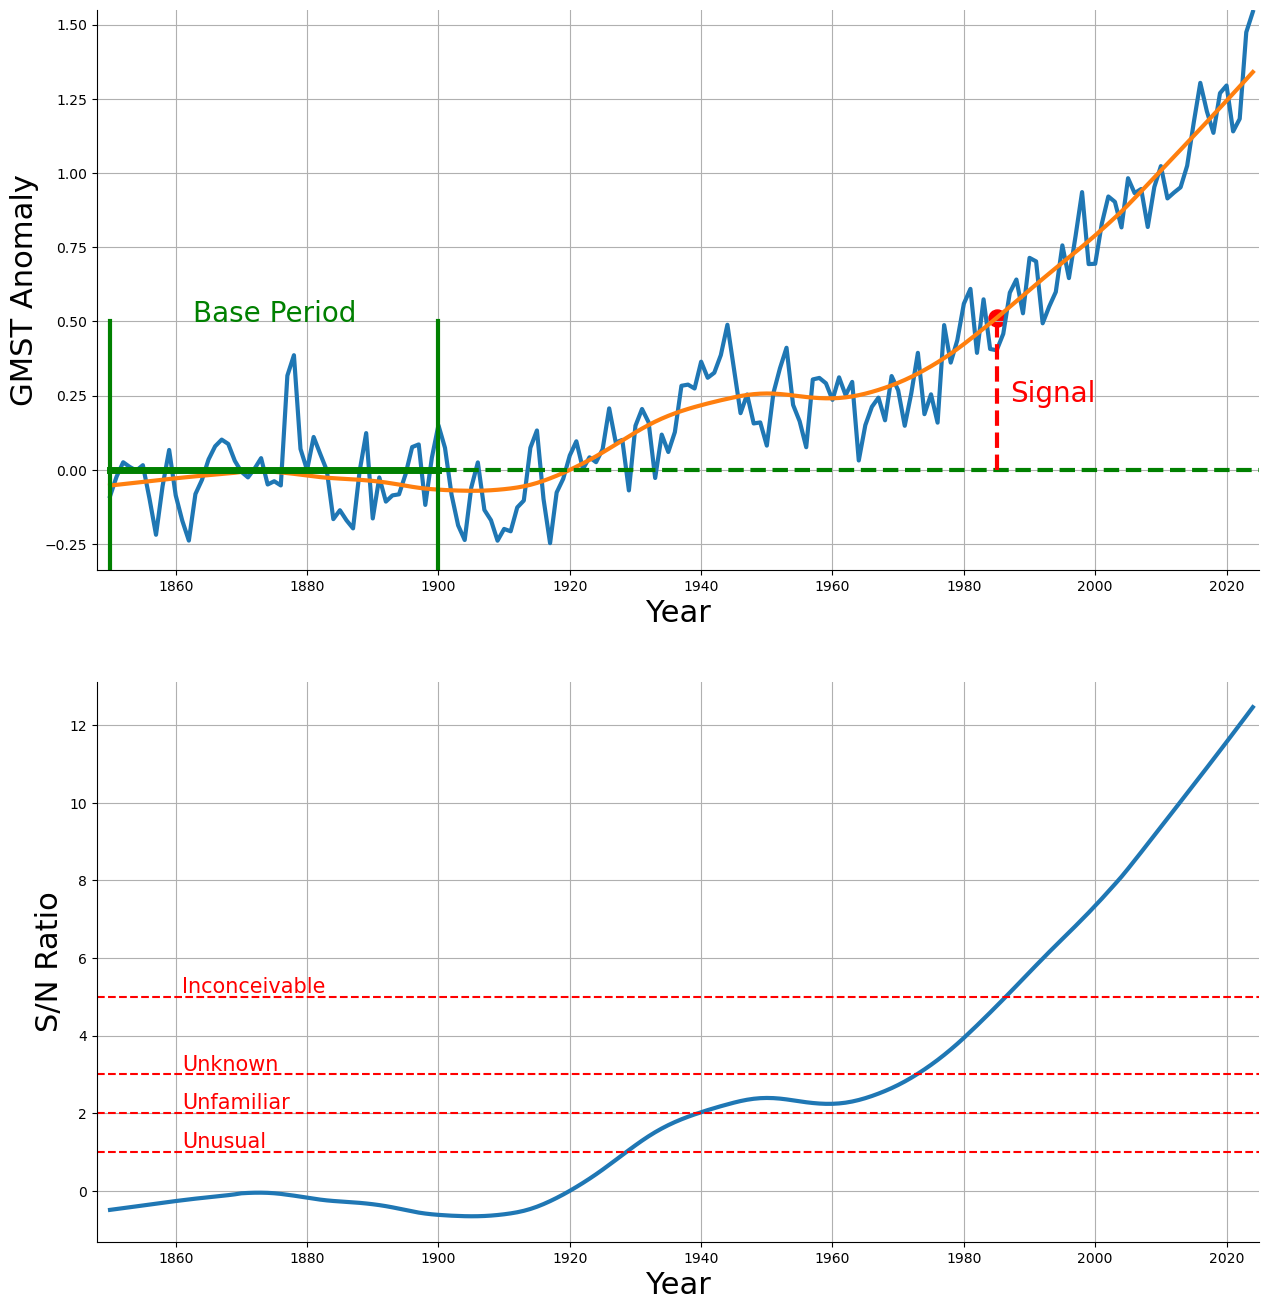

In [190]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))

### Upper aes
time = ds_data_lowess.time.dt.year.values
ax1.plot(time, data_ds_smean.values, linewidth=3)
ax1.plot(time, ds_data_lowess.values, linewidth=3)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('GMST Anomaly', fontsize=22)
ax1.set_xlabel('Year', fontsize=22)
ax1.grid(True)

ylower = ax1.get_ylim()[0]
ax1.plot([1850, 1850], [ylower, 0.5], linewidth=3, color='green')
ax1.plot([1900, 1900], [ylower, 0.5], linewidth=3, color='green')
ax1.plot([1850, 2025], [0, 0], color='green', linewidth=3, linestyle='--')
ax1.plot([1850, 1900], [0, 0], color='green', linewidth=5)

itime = 135
ax1.scatter(time[itime], ds_data_lowess.values[itime], marker='o', s=150,
          color='red')
ax1.plot([time[itime], time[itime]], [0, ds_data_lowess.values[itime]],
       color='red', linewidth=3, linestyle='--')

ax1.annotate('Signal', xy=(time[itime]+2, ds_data_lowess.values[itime]/2), fontsize=20, ha='left', 
            color='red', va='center')

ax1.set_ylim(ylower, 1.55)
ax1.annotate('Base Period', xy=(1875, 0.5), fontsize=20, ha='center', color='green')

ax1.set_xlim(1848, 2025)



### Lower axes

time = ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].time.dt.year.values
ax2.plot(time, ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].values, linewidth=3)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylabel('S/N Ratio', fontsize=22)
ax2.set_xlabel('Year', fontsize=22)
ax2.grid(True)


ax2.set_xlim(1848, 2025)


frame_lines = dict(linestyle='--', color='red')
ax2.axhline(1, **frame_lines)
ax2.annotate('Unusual', xy=(1861, 1), va='bottom', size=15, color='red')
ax2.axhline(2, **frame_lines)
ax2.annotate('Unfamiliar', xy=(1861, 2), va='bottom', size=15, color='red')
ax2.axhline(3, **frame_lines)
ax2.annotate('Unknown', xy=(1861, 3), va='bottom', size=15, color='red')

ax2.axhline(5, **frame_lines)
ax2.annotate('Inconceivable', xy=(1861, 5), va='bottom', size=15, color='red')


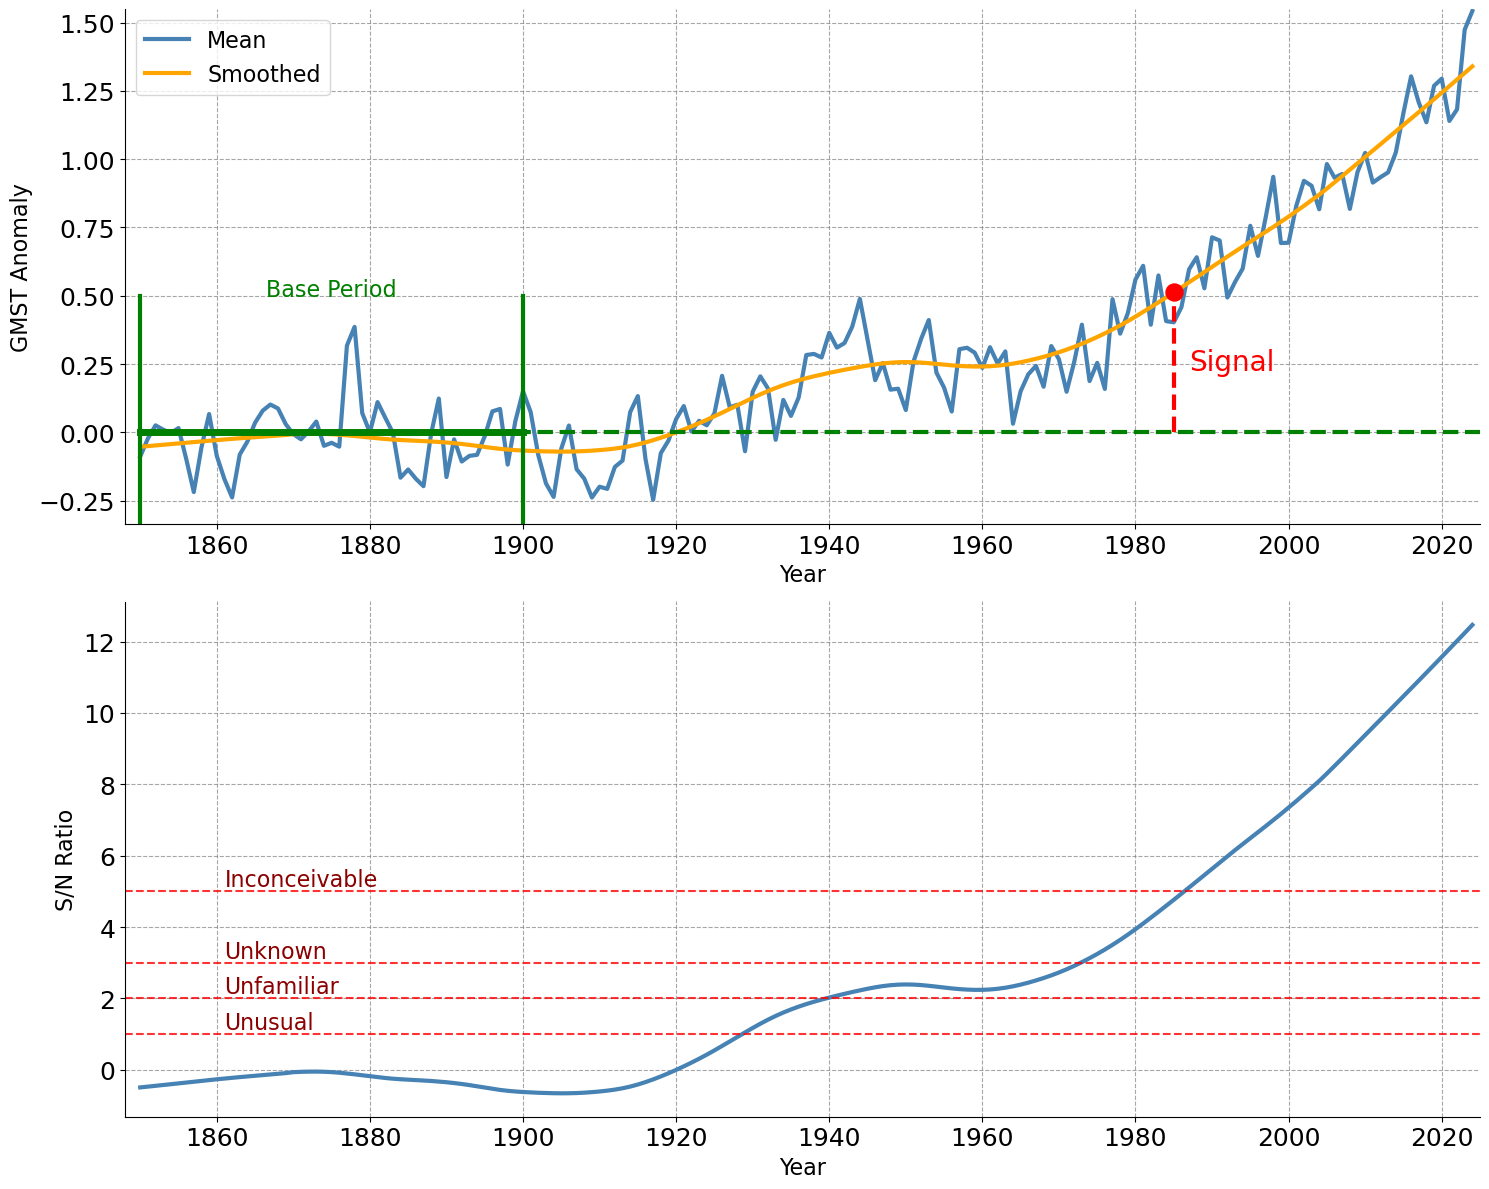

In [191]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

text_size = 16

# --- Upper axes (GMST Anomaly) ---
time = ds_data_lowess.time.dt.year.values
ax1.plot(time, data_ds_smean.values, linewidth=3, label="Mean", color="steelblue")
ax1.plot(time, ds_data_lowess.values, linewidth=3, label="Smoothed", color="orange")

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Axis labels
ax1.set_ylabel('GMST Anomaly', fontsize=text_size)
ax1.set_xlabel('Year', fontsize=text_size)

# Customize tick label sizes
ax1.tick_params(axis='both', labelsize=18)

# Grid customization
ax1.grid(True, which='both', linestyle='--', color='grey', alpha=0.7)

# Green base period annotations
ylower = ax1.get_ylim()[0]
ax1.plot([1850, 1850], [ylower, 0.5], linewidth=3, color='green')
ax1.plot([1900, 1900], [ylower, 0.5], linewidth=3, color='green')
ax1.plot([1850, 2025], [0, 0], color='green', linewidth=3, linestyle='--')
ax1.plot([1850, 1900], [0, 0], color='green', linewidth=5)
ax1.annotate('Base Period', xy=(1875, 0.5), fontsize=text_size, ha='center', color='green')


# Red scatter and annotation for the signal
itime = 135
ax1.scatter(time[itime], ds_data_lowess.values[itime], marker='o', s=150, color='red', zorder=3)
ax1.plot([time[itime], time[itime]], [0, ds_data_lowess.values[itime]], color='red', linewidth=3, 
         linestyle='--')

ax1.annotate('Signal', xy=(time[itime]+2, ds_data_lowess.values[itime]/2), fontsize=20, ha='left', 
            color='red', va='center')

# Other annotations
ax1.set_ylim(ylower, 1.55)

# Axis limits
ax1.set_xlim(1848, 2025)

# Add a legend
ax1.legend(loc="upper left", fontsize=text_size)

# --- Lower axes (S/N Ratio) ---
time_sn = ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].time.dt.year.values
ax2.plot(time_sn, ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].values, linewidth=3, color="steelblue")

# Remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Axis labels
ax2.set_ylabel('S/N Ratio', fontsize=text_size)
ax2.set_xlabel('Year', fontsize=text_size)

# Customize tick label sizes
ax2.tick_params(axis='both', labelsize=18)

# Grid customization
ax2.grid(True, which='both', linestyle='--', color='grey', alpha=0.7)

# Horizontal lines and annotations
frame_lines = dict(linestyle='--', color='red', linewidth=1.5, alpha=0.8)
ax2.axhline(1, **frame_lines)
ax2.annotate('Unusual', xy=(1861, 1), va='bottom', size=text_size, color='darkred')
ax2.axhline(2, **frame_lines)
ax2.annotate('Unfamiliar', xy=(1861, 2), va='bottom', size=text_size, color='darkred')
ax2.axhline(3, **frame_lines)
ax2.annotate('Unknown', xy=(1861, 3), va='bottom', size=text_size, color='darkred')
ax2.axhline(5, **frame_lines)
ax2.annotate('Inconceivable', xy=(1861, 5), va='bottom', size=text_size, color='darkred')

# Axis limits
ax2.set_xlim(1848, 2025)

# Reduce space between the plots
plt.tight_layout()

# Show the plot
plt.show()


<h2 style='color: cyan'> KS Test</h2>

In [192]:
# Assuming ks_emergence_year and base_period_tuple are already defined
ks_emergence_year = int(toe_ds['ks'].values.item())
base_period_end = base_period_tuple[-1]
year_until_emergence = ks_emergence_year - base_period_end
years = np.arange(0, 40, 3) # These are the years after the base period
# The central year will be the end of the base period + 10 (ass middle of 20-years), +year
central_years = base_period_end+10+years
years, central_years

(array([ 0,  3,  6,  9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39]),
 array([1890, 1893, 1896, 1899, 1902, 1905, 1908, 1911, 1914, 1917, 1920,
        1923, 1926, 1929]))

(1.0499999301109606, -0.049999996671950514)

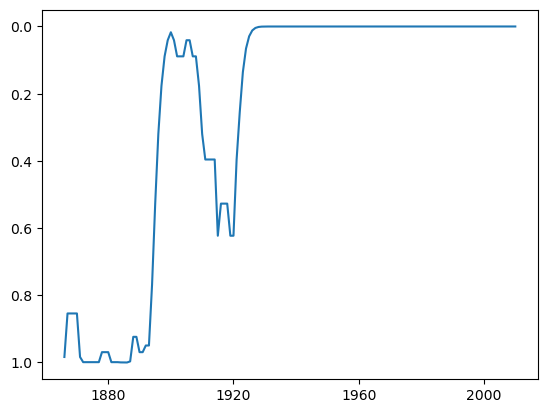

In [193]:
fig, ax2 = plt.subplots(1, 1)
ax2.plot(toe_metrics_ds['ks'].time.values, toe_metrics_ds['ks'].values)
ax2.set_ylim(np.take(ax2.get_ylim(), [-1, 0]))

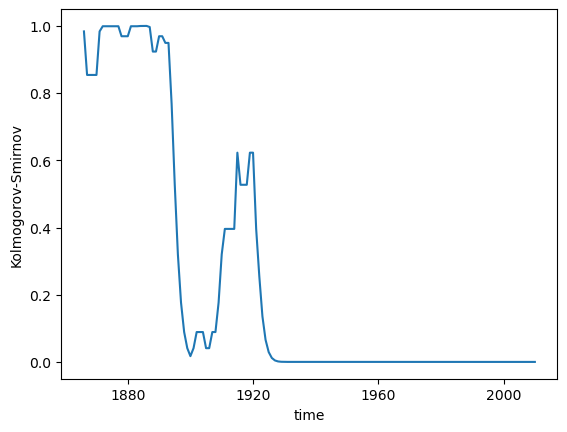

In [194]:
toe_metrics_ds['ks'].plot()

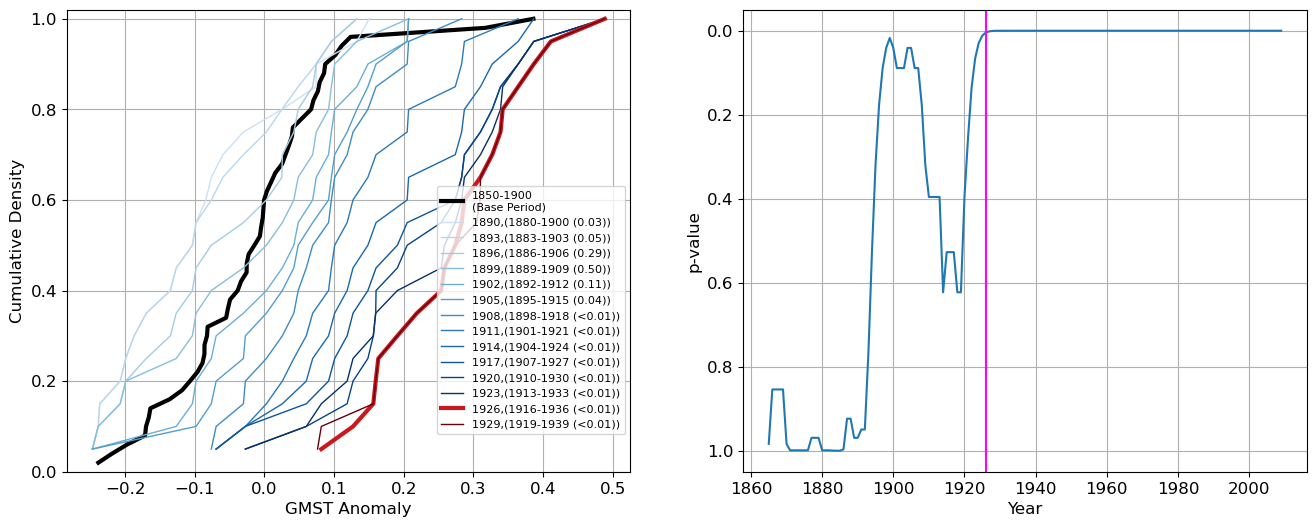

In [195]:
# Set up your plot
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(16, 6))



# Base array for comparison
base_array = data_ds_smean.isel(time=slice(0, 50)).values  # Length 50
ecdf_base = ECDF(base_array)
ax.plot(ecdf_base.x, ecdf_base.y, color='black', linewidth=3, label='1850-1900\n(Base Period)')

# Prepare to calculate KS statistics and p-values
ks_statistics = []
ks_statistics2 = []

p_values = []

# Set up color maps
cmap1 = cm.get_cmap('Blues', sum(central_years < ks_emergence_year) + 3)  
cmap2 = cm.get_cmap('Reds', sum(central_years >= ks_emergence_year) + 3) 

# Loop through the years and calculate ECDFs, KS statistics, and p-values
count = 3
for year, central_year in zip(years, central_years):

    data2 = data_ds_smean.values[50 + year:70 + year]  # Second dataset (length 20)
    ecdf2 = ECDF(data2)

    # Compute KS statistic and p-value using ks_2samp
    ks_statistic2, p_value = ks_2samp(base_array, data2)  # Direct KS test
    ks_statistics2.append(ks_statistic2)  # Store the KS statistic from ks_2samp
    p_values.append(p_value) 

    # Set line width based on conditions
    if ks_emergence_year - 3 < central_year < ks_emergence_year + 3:
        linewidth = 3
        count = 3
        
    else:
        linewidth = 1

    # Get color from colormap
    if central_year < ks_emergence_year:
        color = cmap1(count)
        count += 1
    else:
        color = cmap2(count) 
        count += 1

    # Plot the ECDF for the second dataset
    if p_value < 0.01:
        p_value_str = '<0.01'
    else:
        p_value_str = f'{p_value:.2f}'

    year_str = f'{central_year-10}-{central_year+10}'
    ax.plot(ecdf2.x, ecdf2.y, color=color,
            label=f'{central_year},({year_str} ({p_value_str}))', linewidth=linewidth)


# Set labels, grid, and legend
ax.set_ylabel('Cumulative Density', fontsize=12)
ax.set_xlabel('GMST Anomaly', fontsize=12)
ax.grid(True)
ax.legend(loc='right', bbox_to_anchor=[1.0, 0.35], fontsize=8)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

ax.set_ylim(0, 1.02)

# The second subplot
ax2.plot(toe_metrics_ds['ks'].time.dt.year.values, toe_metrics_ds['ks'].values)
ax2.set_ylim(np.take(ax2.get_ylim(), [-1, 0]))
ax2.grid(True)

ax2.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='x', labelsize=12)

ax2.set_ylabel('p-value', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.axvline(ks_emergence_year, color='magenta')

In [196]:
data_ds_smean

<xarray.DataArray 'temperature' (time: 175)> Size: 1kB
-0.08897 -0.02272 0.02549 0.009678 -0.002542 ... 1.295 1.14 1.182 1.474 1.543
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [197]:
base_period_end + year, base_period_end + year

(1919, 1919)

(0.0, 1.02)

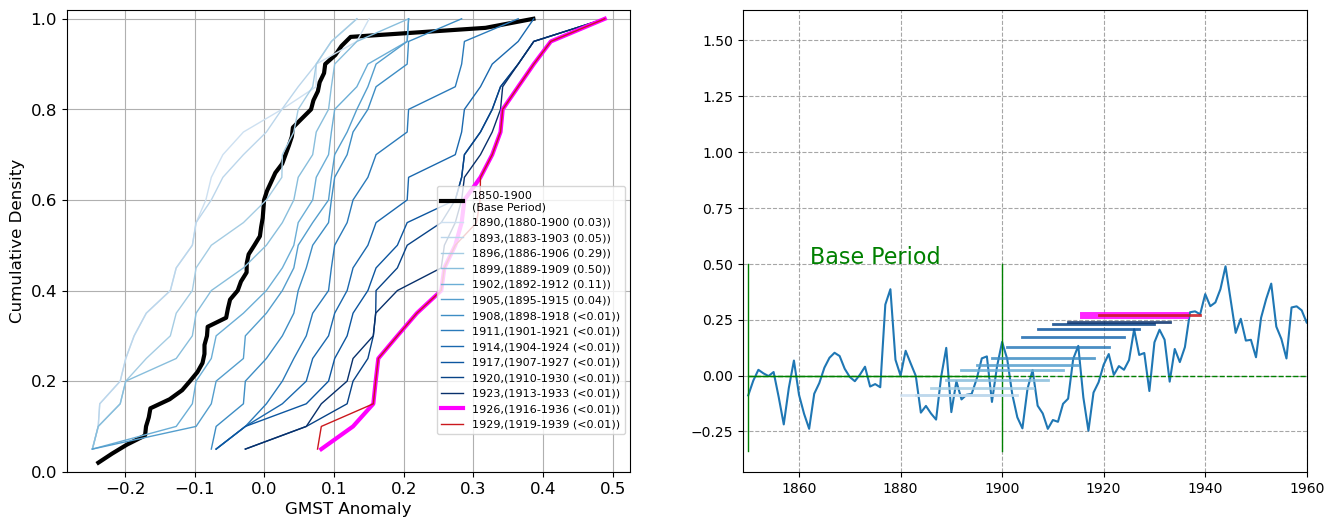

In [198]:
# Set up your plot
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax2.plot(data_ds_smean.time.dt.year.values, data_ds_smean.values)
# Green base period annotations
ylower = ax2.get_ylim()[0]
ax2.plot([1850, 1850], [ylower, 0.5], linewidth=1, color='green')
ax2.plot([1900, 1900], [ylower, 0.5], linewidth=1, color='green')
ax2.plot([1850, 2025], [0, 0], color='green', linewidth=1, linestyle='--')
ax2.plot([1850, 1900], [0, 0], color='green', linewidth=1)
ax2.annotate('Base Period', xy=(1875, 0.5), fontsize=text_size, ha='center', color='green')

ax2.set_xlim(1849, 1960)
ax2.grid(True, which='both', linestyle='--', color='grey', alpha=0.7)

# Base array for comparison
base_array = data_ds_smean.isel(time=slice(0, 50)).values  # Length 50
ecdf_base = ECDF(base_array)
ax.plot(ecdf_base.x, ecdf_base.y, color='black', linewidth=3, label='1850-1900\n(Base Period)')

# Prepare to calculate KS statistics and p-values
ks_statistics = []
ks_statistics2 = []

p_values = []

# Set up color maps
cmap1 = cm.get_cmap('Blues', sum(central_years < ks_emergence_year) + 3)  
cmap2 = cm.get_cmap('Reds', sum(central_years >= ks_emergence_year) + 3) 

# Loop through the years and calculate ECDFs, KS statistics, and p-values
count = 3
for year, central_year in zip(years, central_years):

    data2 = data_ds_smean.values[50 + year:70 + year]  # Second dataset (length 20)
    ecdf2 = ECDF(data2)
    

    # Compute KS statistic and p-value using ks_2samp
    ks_statistic2, p_value = ks_2samp(base_array, data2)  # Direct KS test
    ks_statistics2.append(ks_statistic2)  # Store the KS statistic from ks_2samp
    p_values.append(p_value) 


    


    # Get color from colormap
    if central_year < ks_emergence_year:
        color = cmap1(count)
        count += 1
    else:
        color = cmap2(count) 
        count += 1

        # Set line width based on conditions
    if ks_emergence_year - 3 < central_year < ks_emergence_year + 3:
        linewidth = 3
        count = 3
        linewidth_ax2 = 5
        color='magenta'
        
    else:
        linewidth = 1
        linewidth_ax2 = 2

    # Plot the ECDF for the second dataset
    if p_value < 0.01:
        p_value_str = '<0.01'
    else:
        p_value_str = f'{p_value:.2f}'

    year_str = f'{central_year-10}-{central_year+10}'
    ax.plot(ecdf2.x, ecdf2.y, color=color,
            label=f'{central_year},({year_str} ({p_value_str}))', linewidth=linewidth)

    data2_mean = np.nanmean(data2)
    ax2.plot([base_period_end + year, base_period_end+ 20 + year], [data2_mean, data2_mean],
            color=color, linewidth=linewidth_ax2, alpha=0.85)

    ####


# Set labels, grid, and legend
ax.set_ylabel('Cumulative Density', fontsize=12)
ax.set_xlabel('GMST Anomaly', fontsize=12)
ax.grid(True)
ax.legend(loc='right', bbox_to_anchor=[1.0, 0.35], fontsize=8)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

ax.set_ylim(0, 1.02)

# # The second subplot
# ax2.plot(toe_metrics_ds['ks'].time.dt.year.values, toe_metrics_ds['ks'].values)
# ax2.set_ylim(np.take(ax2.get_ylim(), [-1, 0]))
# ax2.grid(True)

# ax2.tick_params(axis='y', labelsize=12)
# ax2.tick_params(axis='x', labelsize=12)

# ax2.set_ylabel('p-value', fontsize=12)
# ax2.set_xlabel('Year', fontsize=12)
# ax2.axvline(ks_emergence_year, color='magenta')

(0.0, 1.02)

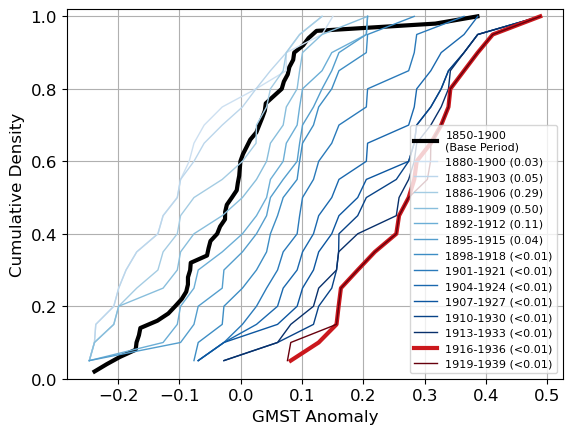

In [199]:
# Set up your plot
fig, ax = plt.subplots(1, 1)

# Assuming ks_emergence_year and base_period_tuple are already defined
ks_emergence_year = int(toe_ds['ks'].values.item())
base_period_end = base_period_tuple[-1]
year_until_emergence = ks_emergence_year - base_period_end

# Base array for comparison
base_array = data_ds_smean.isel(time=slice(0, 50)).values  # Length 50
ecdf_base = ECDF(base_array)
ax.plot(ecdf_base.x, ecdf_base.y, color='black', linewidth=3, label='1850-1900\n(Base Period)')

# Prepare to calculate KS statistics and p-values
ks_statistics = []
ks_statistics2 = []

p_values = []

# Set up color maps
cmap1 = cm.get_cmap('Blues', sum(central_years < ks_emergence_year) + 3)  
cmap2 = cm.get_cmap('Reds', sum(central_years >= ks_emergence_year) + 3) 

# Loop through the years and calculate ECDFs, KS statistics, and p-values
count = 3
for year, central_year in zip(years, central_years):

    data2 = data_ds_smean.values[50 + year:70 + year]  # Second dataset (length 20)
    ecdf2 = ECDF(data2)

    # Create a common grid of values for evaluating ECDFs
    combined_values = np.concatenate([base_array, data2])
    ecdf_combined = np.sort(combined_values)

    # Evaluate the ECDFs at the combined values
    ecdf_base_values = ecdf_base(ecdf_combined)
    ecdf2_values = ecdf2(ecdf_combined)

    # Calculate the KS statistic (maximum difference)
    differences = np.abs(ecdf_base_values - ecdf2_values)
    ks_statistic = np.max(differences)  # Max difference from ECDFs
    ks_statistics.append(ks_statistic)   # Store the KS statistic from ECDFs

    # Compute KS statistic and p-value using ks_2samp
    ks_statistic2, p_value = ks_2samp(base_array, data2)  # Direct KS test
    ks_statistics2.append(ks_statistic2)  # Store the KS statistic from ks_2samp
    p_values.append(p_value) 

    # Set line width based on conditions
    if ks_emergence_year - 3 < central_year < ks_emergence_year + 3:
        linewidth = 3
        count = 3
        
    else:
        linewidth = 1

    # Get color from colormap
    if central_year < ks_emergence_year:
        color = cmap1(count)
        count += 1
    else:
        color = cmap2(count) 
        count += 1

    # Plot the ECDF for the second dataset
    if p_value < 0.01:
        p_value_str = '<0.01'
    else:
        p_value_str = f'{p_value:.2f}'

    year_str = f'{central_year-10}-{central_year+10}'
    ax.plot(ecdf2.x, ecdf2.y, color=color,
            label=f'{year_str} ({p_value_str})', linewidth=linewidth)





# Set labels, grid, and legend
ax.set_ylabel('Cumulative Density', fontsize=12)
ax.set_xlabel('GMST Anomaly', fontsize=12)
ax.grid(True)
ax.legend(loc='right', bbox_to_anchor=[1.0, 0.35], fontsize=8)

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

ax.set_ylim(0, 1.02)

In [200]:
# Print the KS statistics and p-values for each year
for central_year, ks_stat, p_val in zip(central_years, ks_statistics, p_values):
    print(f"KS Statistic for year {central_year}: {ks_stat}, p-value: {p_val}")

KS Statistic for year 1890: 0.37999999999999995, p-value: 0.025179533099176636
KS Statistic for year 1893: 0.35, p-value: 0.048844029818826566
KS Statistic for year 1896: 0.24999999999999997, p-value: 0.29449912551945945
KS Statistic for year 1899: 0.21000000000000008, p-value: 0.5037278503545657
KS Statistic for year 1902: 0.31000000000000005, p-value: 0.10813272558383452
KS Statistic for year 1905: 0.36000000000000004, p-value: 0.03945221556540564
KS Statistic for year 1908: 0.46, p-value: 0.0031886855178668632
KS Statistic for year 1911: 0.56, p-value: 0.00012470093911667402
KS Statistic for year 1914: 0.65, p-value: 3.2928280874369593e-06
KS Statistic for year 1917: 0.75, p-value: 2.196689587238549e-08
KS Statistic for year 1920: 0.8400000000000001, p-value: 7.758744016307761e-11
KS Statistic for year 1923: 0.79, p-value: 2.0697422881437893e-09
KS Statistic for year 1926: 0.91, p-value: 2.5062296896711496e-13
KS Statistic for year 1929: 0.8600000000000001, p-value: 1.81987040975137

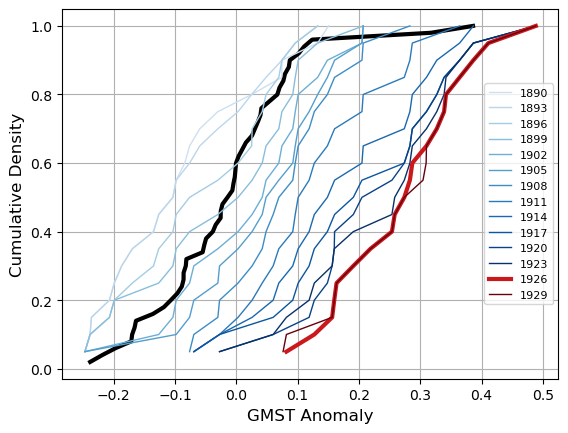

In [201]:
fig, ax = plt.subplots(1, 1)

ks_emergence_year = int(toe_ds['ks'].values.item())
base_period_end = base_period_tuple[-1]
year_until_emergence = ks_emergence_year - base_period_end

number_cdfs = 50

# Set up your color map
cmap1 = cm.get_cmap('Blues', sum(central_years<ks_emergence_year)+3)  
cmap2 = cm.get_cmap('Reds', sum(central_years>=ks_emergence_year)+3) 


base_array = data_ds_smean.isel(time=slice(0,50)).values#[:50]
ecdf_base = ECDF(base_array)
ax.plot(ecdf_base.x, ecdf_base.y, color='black', linewidth=3)  # You can keep the first ECDF in black or another fixed color

# Plot the subsequent ECDFs with a color gradient
count = 3
for year, central_year in zip(years, central_years):
    # central_year = base_period_end+10+year
    
    data2 = data_ds_smean.values[50+year:70+year]
    ecdf2 = ECDF(data2)
    if ks_emergence_year-3<central_year<ks_emergence_year+3:
        linewidth = 3
        count = 3
    else: linewidth = 1
    
    # Get color from colormap
    if central_year < ks_emergence_year:
        color = cmap1(count)
        count += 1
    else:
        color = cmap2(count) 
        count +=1



    ax.plot(ecdf2.x, ecdf2.y, color=color, label=central_year,linewidth=linewidth) 

ax.set_ylabel('Cumulative Density', fontsize=12)
ax.set_xlabel('GMST Anomaly', fontsize=12)
ax.grid(True)
ax.legend(loc='right', bbox_to_anchor=[1.0, 0.5], fontsize=8)  

Text(1875, 0.5, 'Base Period')

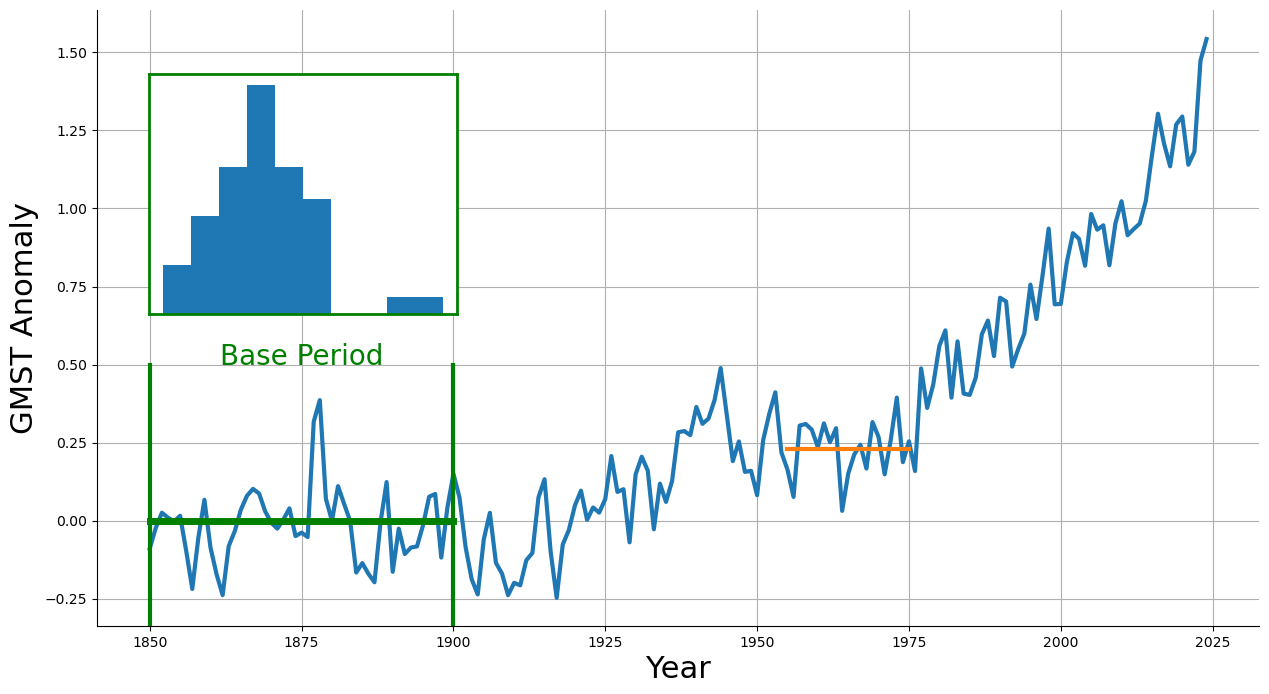

In [202]:
fig, ax = plt.subplots(figsize=(15, 8))
time = data_ds_smean.time.dt.year.values
ax.plot(time, data_ds_smean.values, linewidth=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('GMST Anomaly', fontsize=22)
ax.set_xlabel('Year', fontsize=22)
ax.grid(True)

ylower = ax.get_ylim()[0]
ax.plot([1850, 1850], [ylower, 0.5], linewidth=3, color='green')
ax.plot([1900, 1900], [ylower, 0.5], linewidth=3, color='green')
ax.plot([1850, 1900], [0, 0], color='green', linewidth=5)

inner_ax = fig.add_axes([0.16, 0.5, 0.205, 0.3])  # [left, bottom, width, height]
inner_ax.set_xticks([])
inner_ax.set_yticks([])
inner_ax.hist(data_ds_smean.values[:50])

# Set the spine colors and increase their width for the inner plot
for spine in inner_ax.spines.values():
    spine.set_color('green')  # Set color to green
    spine.set_linewidth(2)     # Set the linewidth to 2


central_year = 115

subset = data_ds_smean.values[central_year-10:central_year+10]
ax.plot([1850+central_year-10, 1850+central_year+10], np.tile(np.mean(subset), 2),
       linewidth=3)

ax.set_ylim(ylower, ax.get_ylim()[-1])
ax.annotate('Base Period', xy=(1875, 0.5), fontsize=20, ha='center', color='green')

<h2 style='color: cyan'>Overlap Methods </h2>

In [203]:
base_arr = data_ds_smean.isel(time=slice(0, 50))

In [204]:
start =70
arr = data_ds_smean.isel(time=slice(start, start+20)).values

In [205]:
num_bins = 25

bmax = np.nanmax(np.concatenate([base_arr, arr]))*1.2
bmin = np.nanmin(np.concatenate([base_arr, arr]))*1.2


# Define the bin width and create bin edges
bins = np.linspace(bmin, bmax, num_bins)

In [206]:
_, pdf_base = toe.discrete_pdf(base_arr, bins)
_, pdf_arr = toe.discrete_pdf(arr, bins)

In [207]:
pps_overlap = toe.discrete_distribution_overlap(pdf_base, pdf_arr)

Text(0, 0.5, 'Relative Frequency')

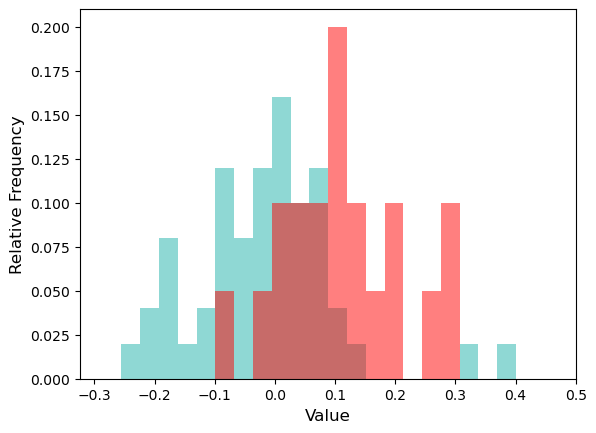

In [208]:
# Plot the PDF as a bar plot
plt.bar(bins[:-1], pdf_base, width=np.diff(bins), align='edge', label='Base Period',
       color='lightseagreen', alpha=0.5)
plt.bar(bins[:-1], pdf_arr, width=np.diff(bins), align='edge', label='Base Period',
       color='red', alpha=0.5)

plt.xlabel('Value', fontsize=12)
plt.ylabel('Relative Frequency', fontsize=12)


In [209]:
reload(toe)

<module 'toe_calc' from '/home/563/ab2313/Documents/time_of_emergene_drafts/src/toe_calc.py'>

In [210]:
x_kde, kde_vals1, kde_vals2, fga_overlap = toe.fractional_geometric_area(
    base_arr, arr, return_all=True, method_kwargs=dict(bw_method=0.2))#'silverman'))
# bw_method=0.2, 

Text(0.5, 1.0, 'Area of Overlap (49%)')

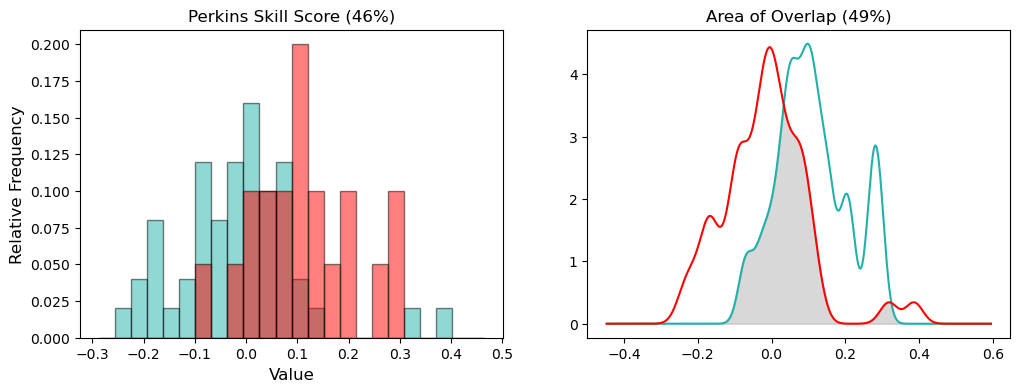

In [211]:
# Plot the PDF as a bar plot

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.bar(bins[:-1], pdf_base, width=np.diff(bins), align='edge', label='Base Period',
       color='lightseagreen', alpha=0.5, edgecolor='k')
ax1.bar(bins[:-1], pdf_arr, width=np.diff(bins), align='edge', label='Base Period',
       color='red', alpha=0.5, edgecolor='k')


# Calculate the overlap
# overlap = np.minimum(pdf_base, pdf_arr)

# # Add the hatching pattern for overlapping regions
# ax1.bar(bins[:-1], overlap, width=np.diff(bins), align='edge', color='none', alpha=0,
#         hatch='/', edgecolor=None)


ax1.set_xlabel('Value', fontsize=12)
ax1.set_ylabel('Relative Frequency', fontsize=12)

ax1.set_title(f'Perkins Skill Score ({pps_overlap:.0f}%)')

ax2.plot(x_kde, kde_vals1, color='lightseagreen')
ax2.plot(x_kde, kde_vals2, color='red')
ax2.fill_between(x_kde, 0, np.min(np.vstack([kde_vals1, kde_vals2]), axis=0),
                 color='gray', alpha=0.3)

ax2.set_title(f'Area of Overlap ({fga_overlap:.0f}%)')


Text(0.5, 1.0, 'Hellinger Distance = 53%')

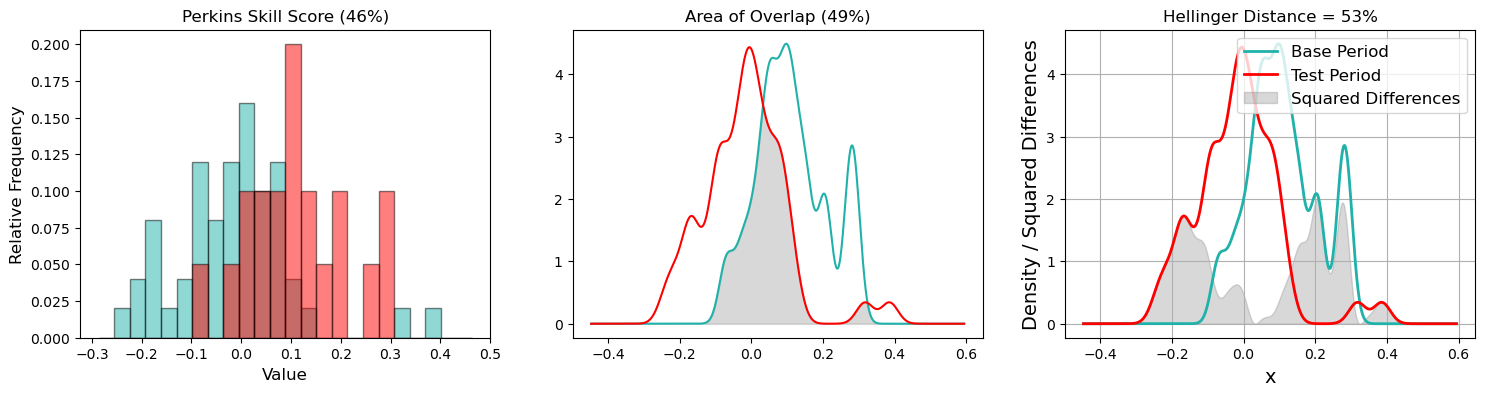

In [212]:
# Plot the PDF as a bar plot

fig = plt.figure(figsize=(18, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)


ax1.bar(bins[:-1], pdf_base, width=np.diff(bins), align='edge', label='Base Period',
       color='lightseagreen', alpha=0.5, edgecolor='k')
ax1.bar(bins[:-1], pdf_arr, width=np.diff(bins), align='edge', label='Base Period',
       color='red', alpha=0.5, edgecolor='k')


# Calculate the overlap
# overlap = np.minimum(pdf_base, pdf_arr)

# # Add the hatching pattern for overlapping regions
# ax1.bar(bins[:-1], overlap, width=np.diff(bins), align='edge', color='none', alpha=0,
#         hatch='/', edgecolor=None)

### FGA
ax1.set_xlabel('Value', fontsize=12)
ax1.set_ylabel('Relative Frequency', fontsize=12)

ax1.set_title(f'Perkins Skill Score ({pps_overlap:.0f}%)')

ax2.plot(x_kde, kde_vals1, color='lightseagreen')
ax2.plot(x_kde, kde_vals2, color='red')
ax2.fill_between(x_kde, 0, np.min(np.vstack([kde_vals1, kde_vals2]), axis=0),
                 color='gray', alpha=0.3)

ax2.set_title(f'Area of Overlap ({fga_overlap:.0f}%)')



#### Hellinger Distance

P = kde_vals1
Q = kde_vals2

squared_diff = (np.sqrt(P) - np.sqrt(Q))**2

hellinger_distance = np.sqrt(np.sum(squared_diff) * (x_kde[1] - x_kde[0])) / np.sqrt(2)

# Plot the original distributions
ax3.plot(x_kde, P, label=f'Base Period', color='lightseagreen', linewidth=2)
ax3.plot(x_kde, Q, label=f'Test Period', color='red', linewidth=2)


#ax3Fill the area under the squared differences
plt.fill_between(x_kde, 0, squared_diff, color='gray', alpha=0.3,
                 label=f'Squared Differences')


# Add titles and labels
ax3.set_xlabel('x', fontsize=14)
ax3.set_ylabel('Density / Squared Differences', fontsize=14)
ax3.legend(loc='upper right', fontsize=12)
ax3.grid(True)
ax3.set_title(f'Hellinger Distance = {hellinger_distance*100:.0f}%')

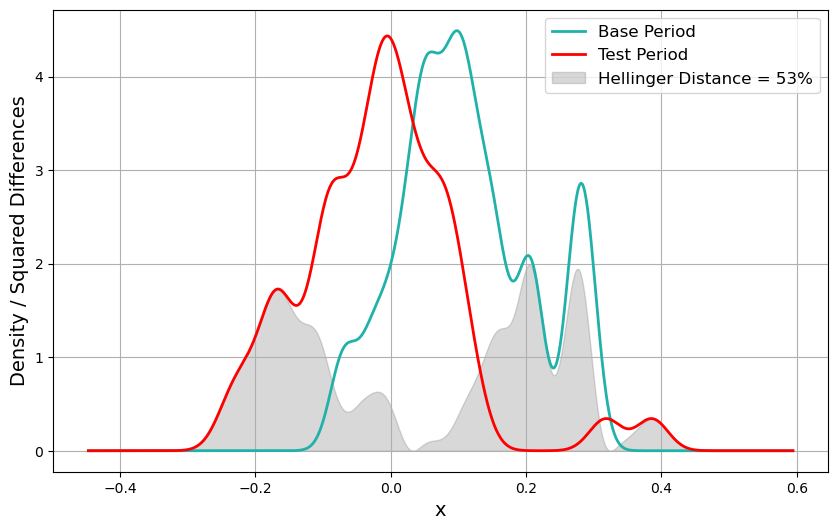

In [213]:
P = kde_vals1
Q = kde_vals2

squared_diff = (np.sqrt(P) - np.sqrt(Q))**2

hellinger_distance = np.sqrt(np.sum(squared_diff) * (x_kde[1] - x_kde[0])) / np.sqrt(2)

# Plot the original distributions
plt.figure(figsize=(10, 6))
plt.plot(x_kde, P, label=f'Base Period', color='lightseagreen', linewidth=2)
plt.plot(x_kde, Q, label=f'Test Period', color='red', linewidth=2)


# Fill the area under the squared differences
plt.fill_between(x_kde, 0, squared_diff, color='gray', alpha=0.3,
                 label=f'Hellinger Distance = {hellinger_distance*100:.0f}%')


# Add titles and labels
plt.xlabel('x', fontsize=14)
plt.ylabel('Density / Squared Differences', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)


<h2 style='color: cyan'> Figure Merge </h2>

In [223]:
def format_timeseries_ax(ax):
    start_year = int(data_ds_smean.time.dt.year.min())
    end_year = int(data_ds_smean.time.dt.year.max())
    tick_start = 25 * (start_year // 25)
    ax.set_xlim(start_year - 3, end_year + 1)
    ax.grid(True, linestyle='--', color='grey', alpha=0.6)
    ax.set_xticks(np.arange(tick_start, end_year + 1, 25))
    ax.set_xlabel('Year', fontsize=SHCEMATIC_FIGURE_DICT['labels'])


In [224]:
def change_tick_size(ax, tick_size=10, label_size:float=SHCEMATIC_FIGURE_DICT['labels']):
    ax.tick_params(axis='x', which='both', size=SHCEMATIC_FIGURE_DICT['tick_size'], labelsize=label_size)
    ax.tick_params(axis='y', which='both', size=SHCEMATIC_FIGURE_DICT['tick_size'], labelsize=label_size)

In [225]:
def convert_multi_to_name(arr):
    '''
    Same have the same ToE - so give just one line and bloth all with that lavel
    '''
    if len(arr) == 1:
        return toe_const.NAME_CONVERSION_DICT_SHORT.get(arr[0], arr[0])
    
    return '(' + ', '.join(toe_const.NAME_CONVERSION_DICT_SHORT.get(toe_metric, toe_metric) for toe_metric in arr) + ')'

In [226]:
SHCEMATIC_FIGURE_DICT = {
    'base_color': 'lightseagreen',
    'future_color': 'red', 
    'title_fontsize': 15,
    'other_text': 10,
    'labels': 14,
    'linewidth': 2,
    'tick_size':1,
    'legend_elements': 14
}

In [227]:
toe_df = toe_ds.to_pandas().astype(int)
toe_df

sn_poly_full      1939
sn_lowess_full    1929
sn_mean_full      1929
sn_anom           1965
ks                1926
ttest             1926
frac              1928
hd                1945
nn                1979
dtype: int64

In [229]:
main_metrics = ['sn_poly_full', 'sn_lowess_full', 'sn_mean_full', 'sn_anom', 'sn_ens_med_full', 'ks', 'ttest', 'frac', 'hd', 'pr', 'nn']
main_metrics = [metric for metric in main_metrics if metric in toe_df.columns]
toe_subset_df = toe_df[main_metrics]
toe_labels = toe_subset_df.groupby(toe_subset_df).apply(lambda x: list(x.index))
toe_labels = toe_labels.apply(lambda x: convert_multi_to_name(x))
toe_labels


1926                      (KS, T-Test)
1928                                AO
1929    (sn_lowess_full, sn_mean_full)
1939                      sn_poly_full
1945                                HD
1965                        S/N (Anom)
1979                                NN
dtype: object

In [4]:

def lower_pannels(
    fig: Optional[Figure] = None,
    ax1: Optional[Axes] = None,
    ax2: Optional[Axes] = None,
    ax3: Optional[Axes] = None
) -> Tuple[Figure, Axes, Axes, Axes]:
    
    if fig is None or ax1 is None or ax2 is None:
        fig = plt.figure(figsize=(18, 4))
        ax1 = fig.add_subplot(131)
        ax2 = fig.add_subplot(132)
        ax3 = fig.add_subplot(133)

    axes = [ax1, ax2, ax3]



    start_year = int(data_ds_smean.time.dt.year.values[0])
    base_arr = data_ds_smean.isel(time=slice(0, 50))
    
    # fgs_emergence_year = 1928
    fgs_emergence_year = toe_df['frac']
    start_arr = fgs_emergence_year - start_year - 15# + 4

    arr = data_ds_smean.isel(time=slice(start_arr, start_arr+30)).values
    
    bmax = 0.6#np.nanmax(np.concatenate([base_arr, arr]))*1.2
    bmin = -0.6#np.nanmin(np.concatenate([base_arr, arr]))*1.2

    x_kde, kde_vals_future, kde_vals_base, fga_overlap = toe.fractional_geometric_area(
        base_arr, arr, return_all=True, method_kwargs=dict(bw_method=0.2), bmin=bmin, bmax=bmax)#'silverman'))


    # ALl thre plots use the same kde distributions
    for i,ax in enumerate(axes):
        ax.plot(x_kde, kde_vals_base,
                color=SHCEMATIC_FIGURE_DICT['base_color'],
                linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], alpha=0.5,
                label='Base Period' if i==0 else None)
        ax.plot(x_kde, kde_vals_future,
                color=SHCEMATIC_FIGURE_DICT['future_color'],
                linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], alpha=0.5,
                label='Future Climate' if i==0 else None)
    ### t-test

    mean_base = np.mean(base_arr).item()
    mean_future = np.mean(arr)
    kde_at_mean_base = kde_vals_base[np.argmin(np.abs(x_kde - mean_base))]
    kde_at_mean_future = kde_vals_future[np.argmin(np.abs(x_kde - mean_future))]

    ax1.annotate(r'$\mu_{base}$', xy=(mean_base, kde_at_mean_base+0.5), ha='center', 
                color=SHCEMATIC_FIGURE_DICT['base_color'], size=20)
    
    ax1.annotate(r'$\mu_{future}$', xy=(mean_future, kde_at_mean_future+0.5), ha='left', 
                color=SHCEMATIC_FIGURE_DICT['future_color'], size=20)
    
    ax1.plot([mean_base, mean_base], [0, kde_at_mean_base],
             color=SHCEMATIC_FIGURE_DICT['base_color'],
             linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    
    ax1.plot([mean_future, mean_future], [0, kde_at_mean_future],
             color=SHCEMATIC_FIGURE_DICT['future_color'],
             linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    
    ### Area of Overlap
    ax2.fill_between(x_kde, 0, np.min(np.vstack([kde_vals_base, kde_vals_future]), axis=0),
                     color='gray', alpha=0.5, label='Distribution\nOverlap')
    
    
    #### Hellinger Distance
    squared_diff = (np.sqrt(kde_vals_base) - np.sqrt(kde_vals_future))**2
    hellinger_distance = np.sqrt(np.sum(squared_diff) * (x_kde[1] - x_kde[0])) / np.sqrt(2)

    
    ax3.fill_between(x_kde, 0, squared_diff, color='gray', alpha=0.5,
                     label=f'Squared\nDifferences')
    ax3.plot(x_kde, squared_diff, color='gray', linewidth=1.5)
    
    # Add titles and labels
    for ax in axes:
        change_tick_size(ax, tick_size=8)
        ax.set_xlim(-0.8, 0.8)
        ax.set_ylim(0, 6)

    for ax in [ax2, ax3]:
        ax.axvline(0, color='k', alpha=0.4)
        
    ax2.set_xlabel(r'Temperature Anomaly ($^\circ$C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    
    ax1.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    
    ax1.set_title(f'T-Test', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax2.set_title(f'Area\nof Overlap ({fga_overlap:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax3.set_title(f'Hellinger\nDistance ({hellinger_distance*100:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    bbox_to_anchor = (1.7, -0.5)
    ax1.legend(loc='lower center', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'] *1.2, ncol=2,
               bbox_to_anchor=bbox_to_anchor)
    ax2.legend(loc='upper left', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'], ncol=2)#bbox_to_anchor=bbox_to_anchor)
    ax3.legend(loc='upper left', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'], ncol=2) #bbox_to_anchor=bbox_to_anchor)

def plot_gmst_and_toe(fig=None, ax=None):
    main_metrics = ['PSS', 'KS', 'Mean', 'ens']
    if fig is None and ax is None:
        fig = plt.figure(figsize=(12, 6))
        ax = fig.add_subplot(111)
    time = data_ds_smean.time.dt.year.values
    arr = data_ds_smean.values
    if ensemble_dim in data_ds_smean_ens.dims and data_ds_smean_ens.sizes.get(ensemble_dim, 1) > 1:
        for member_i in range(data_ds_smean_ens.sizes[ensemble_dim]):
            ax.plot(time, data_ds_smean_ens.isel({ensemble_dim: member_i}).values, color='gray', alpha=0.08, linewidth=0.8)
    ax.plot(time, arr, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], color='black', label='Ensemble median')
    for i, (year, toe_metrics) in enumerate(toe_labels.items()):
        colour = colors[i % len(colors)]
        if not any(mm in toe_metrics for mm in main_metrics):
            line_format_dict = dict(linestyle='-', alpha=0.5, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'] + 0.5)
        else:
            line_format_dict = dict(linestyle='-', alpha=1, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'] + 0.5)
        final_label = toe_metrics
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.35, yval], color=colour, label=final_label, **line_format_dict)
        ax.scatter([year], [yval], color=colour, s=50, zorder=100)
    leg = ax.legend(fontsize=SHCEMATIC_FIGURE_DICT['labels'], labelspacing=0.2, handletextpad=0.2, loc='upper left', ncol=2)
    leg.set_title('Method')
    leg.get_title().set_fontsize(SHCEMATIC_FIGURE_DICT['labels'])
    ylower = ax.get_ylim()[0]
    base_box_kwargs = dict(linewidth=3, color=SHCEMATIC_FIGURE_DICT['base_color'])
    ax.plot([base_period_tuple[0], base_period_tuple[0]], [ylower, 0.5], **base_box_kwargs)
    ax.plot([base_period_tuple[-1], base_period_tuple[-1]], [ylower, 0.5], **base_box_kwargs)
    end_year = int(data_ds_smean.time.dt.year.max())
    ax.plot([base_period_tuple[0], end_year], [0, 0], linestyle='--', **base_box_kwargs)
    ax.plot([base_period_tuple[0], base_period_tuple[-1]], [ylower, ylower], **base_box_kwargs)
    ax.plot([base_period_tuple[0], base_period_tuple[-1]], [0.5, 0.5], **base_box_kwargs)
    ax.annotate('Base Period', xy=(np.mean(base_period_tuple), 0.53), fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'], ha='center', color=SHCEMATIC_FIGURE_DICT['base_color'])
    ax.set_ylabel(r'GMST Anomaly ($^\circ$ C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    format_timeseries_ax(ax)
    change_tick_size(ax, tick_size=8)
    ax.set_ylim(-0.35, 1.5)

def ks_test_figure_v2(
    base_data: xr.DataArray,
    base_period: Tuple[int, int],
    emergence_year: int,
    emergence_window: int = 10,
    fig: Optional[Figure] = None,
    ax: Optional[Axes] = None,
) -> Tuple[Figure, Axes]:
    """Plot KS test comparing base period to emergence period CDFs.
    
    Parameters
    ----------
    base_data : xr.DataArray
        Time series data with 'time' coordinate
    base_period : Tuple[int, int]
        Start and end years of base period
    emergence_year : int
        Central year of emergence period
    emergence_window : int, optional
        Half-width of emergence period window (default: 10 years)
    fig, ax : optional
        Existing figure and axes to plot on
    """
    
    if fig is None or ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Get data for both periods
    base_array = base_data.sel(
        time=slice(str(base_period[0]), str(base_period[1]))
    ).values
    
    emergence_array = base_data.sel(
        time=slice(f'{emergence_year - emergence_window}', 
                   f'{emergence_year + emergence_window}')
    ).values
    
    # Calculate ECDFs
    ecdf_base = ECDF(base_array)
    ecdf_emergence = ECDF(emergence_array)
    
    # KS test
    ks_result = ks_2samp(base_array, emergence_array)
    
    # Plot CDFs
    ax.plot(ecdf_base.x, ecdf_base.y, 
            color=SHCEMATIC_FIGURE_DICT['base_color'],
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], 
            label='CDF of Base Period')
    
    ax.plot(ecdf_emergence.x, ecdf_emergence.y,
            color=SHCEMATIC_FIGURE_DICT['future_color'],
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'],
            label='CDF at Emergence')
    
    # Plot max KS statistic location
    x_values = np.unique(np.concatenate((ecdf_base.x, ecdf_emergence.x)))
    y_distances = np.abs(ecdf_base(x_values) - ecdf_emergence(x_values))
    max_idx = np.argmax(y_distances)
    # Plot max KS statistic location
    # Use the statistic_location from ks_result directly
    max_x = ks_result.statistic_location
    
    # Get the actual CDF values at this location
    max_y_base = ecdf_base(max_x)
    max_y_emergence = ecdf_emergence(max_x)
    
    print(f"max_x: {max_x}, max_y_base: {max_y_base}, max_y_emergence: {max_y_emergence}")
    
    ax.plot([max_x, max_x], [max_y_base, max_y_emergence+0.05],
            color='k', linestyle='--', linewidth=1.5,
            label=f'Max KS Statistic (D = {ks_result.statistic:.2f})')
    ax.scatter([max_x], [max_y_base], 
               color=SHCEMATIC_FIGURE_DICT['base_color'], s=50, zorder=1000)
    ax.scatter([max_x], [max_y_emergence+0.05], 
               color=SHCEMATIC_FIGURE_DICT['future_color'], s=50, zorder=1000)
    
    # Formatting
    ax.set_ylabel('Cumulative Density', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax.set_xlabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax.grid(True, linestyle='--', color='grey', alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim(0, 1.02)
    ax.set_title('Kolmogorov-Smirnov Test', 
                 fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])
    change_tick_size(ax, tick_size=8)
    
    return fig, ax

ks_emergence_year = int(toe_ds['ks'].values.item())
fig, ax = ks_test_figure_v2(
    base_data=data_ds_smean,
    base_period=base_period_tuple,
    emergence_year=ks_emergence_year
)


def sn_ratio_figure_v2(
    fig: Optional[Figure] = None,
    ax2: Optional[Axes] = None,
    fontscale: float = 1,
) -> Tuple[Figure, Axes, Axes]:

    if fig is None or ax2 is None:
        fig, ax2 = plt.subplots(1, 1, figsize=(8, 6))

    sn_vars = ['sn_lowess_full', 'sn_mean_full', 'sn_poly_full', 'sn_anom', 'sn_ens_med_full']
    sn_vars = [sn_name for sn_name in sn_vars if sn_name in toe_metrics_ds.data_vars]
    colors_here = np.take(colors, [1, 2, 3, 5, 0], mode='wrap')

    for i, sn_name in enumerate(sn_vars):
        alpha = 0.35 if sn_name == 'sn_anom' else 1
        ax2.plot(
            toe_metrics_ds.time.dt.year.values,
            toe_metrics_ds[sn_name].values,
            color=colors_here[i],
            label=toe_const.NAME_CONVERSION_DICT_SHORT.get(sn_name, sn_name),
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'],
            alpha=alpha
        )

    ax2.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])
    format_timeseries_ax(ax2)
    xpost_label = int(data_ds_smean.time.dt.year.min()) + 1
    frame_lines = dict(linestyle='--', color='red')
    ax2.axhline(1, **frame_lines)
    ax2.annotate('Unusual', xy=(xpost_label, 1), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(2, **frame_lines)
    ax2.annotate('Unfamiliar', xy=(xpost_label, 2), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(3, **frame_lines)
    ax2.annotate('Unknown', xy=(xpost_label, 3), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(5, **frame_lines)
    ax2.annotate('Inconceivable', xy=(xpost_label, 5), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.set_ylabel('S/N Ratio', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax2.set_title('Signal-to-noise (S/N) Ratio', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    change_tick_size(ax2, tick_size=8)

    return fig, ax2
 


def probability_ratio_figure_v2(
    data_ens: Optional[xr.DataArray] = None,
    base_period: Tuple[int, int] = base_period_tuple,
    event_quantile: float = 0.95,
    rolling_window: int = 30,
    fig: Optional[Figure] = None,
    ax_prob: Optional[Axes] = None,
    ax_pr: Optional[Axes] = None,
) -> Tuple[Figure, Axes, Axes, xr.DataArray]:
    """Demonstration plot for Probability Ratio (PR) using ensemble exceedance rates.

    Event definition: GMST anomaly > base-period q-quantile.
    PR(t) = p1(t) / p0, where p1 is rolling event probability and
    p0 is base-period event probability.
    """

    if data_ens is None:
        data_ens = data_ds_smean_ens

    ens_dims = []
    if ensemble_dim in data_ens.dims and data_ens.sizes.get(ensemble_dim, 1) > 1:
        ens_dims = [ensemble_dim]

    base_slice = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    q_dims = ['time'] + ens_dims
    event_threshold = float(base_slice.quantile(event_quantile, dim=q_dims).values.item())

    event_da = xr.where(data_ens > event_threshold, 1.0, 0.0)

    base_event = event_da.sel(time=slice(str(base_period[0]), str(base_period[1])))
    p0 = float(base_event.mean(dim=q_dims).values.item())
    p0_safe = max(p0, 1e-6)

    p1 = event_da.rolling(time=rolling_window, center=True).mean()
    if ens_dims:
        p1 = p1.mean(dim=ens_dims)

    pr_da = p1 / p0_safe

    if fig is None or ax_prob is None or ax_pr is None:
        fig, (ax_prob, ax_pr) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    years = pr_da.time.dt.year.values

    ax_prob.plot(years, p1.values, color='tab:blue', linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='Rolling event probability $p_1(t)$')
    ax_prob.axhline(p0, color='tab:orange', linestyle='--', linewidth=2, label=f'Base probability $p_0$ = {p0:.3f}')
    ax_prob.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_prob.set_title('Event Probability: Base vs Rolling', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax_prob.grid(True, linestyle='--', alpha=0.5)
    ax_prob.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])

    ax_pr.plot(years, pr_da.values, color='tab:purple', linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='PR = $p_1(t)/p_0$')
    ax_pr.axhline(1, color='red', linestyle='--', linewidth=1.8)
    ax_pr.axhline(2, color='red', linestyle=':', linewidth=1.5)
    ax_pr.annotate('No change (PR=1)', xy=(years[5], 1.02), color='red', fontsize=SHCEMATIC_FIGURE_DICT['other_text'])
    ax_pr.annotate('PR=2', xy=(years[5], 2.05), color='red', fontsize=SHCEMATIC_FIGURE_DICT['other_text'])
    ax_pr.set_ylabel('Probability Ratio', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_pr.set_xlabel('Year', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_pr.set_title('Probability Ratio Demonstration', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax_pr.grid(True, linestyle='--', alpha=0.5)
    ax_pr.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])

    for ax in [ax_prob, ax_pr]:
        format_timeseries_ax(ax)
        change_tick_size(ax, tick_size=8)

    return fig, ax_prob, ax_pr, pr_da

SHCEMATIC_FIGURE_DICT = {
    'base_color': 'lightseagreen',
    'future_color': 'red', 
    'title_fontsize': 23, #15
    'other_text': 14, #10
    'labels': 23, #15
    'legend_elements': 15, 
    'tick_size': 12,
    'linewidth': 3 #2
}




NameError: name 'Figure' is not defined

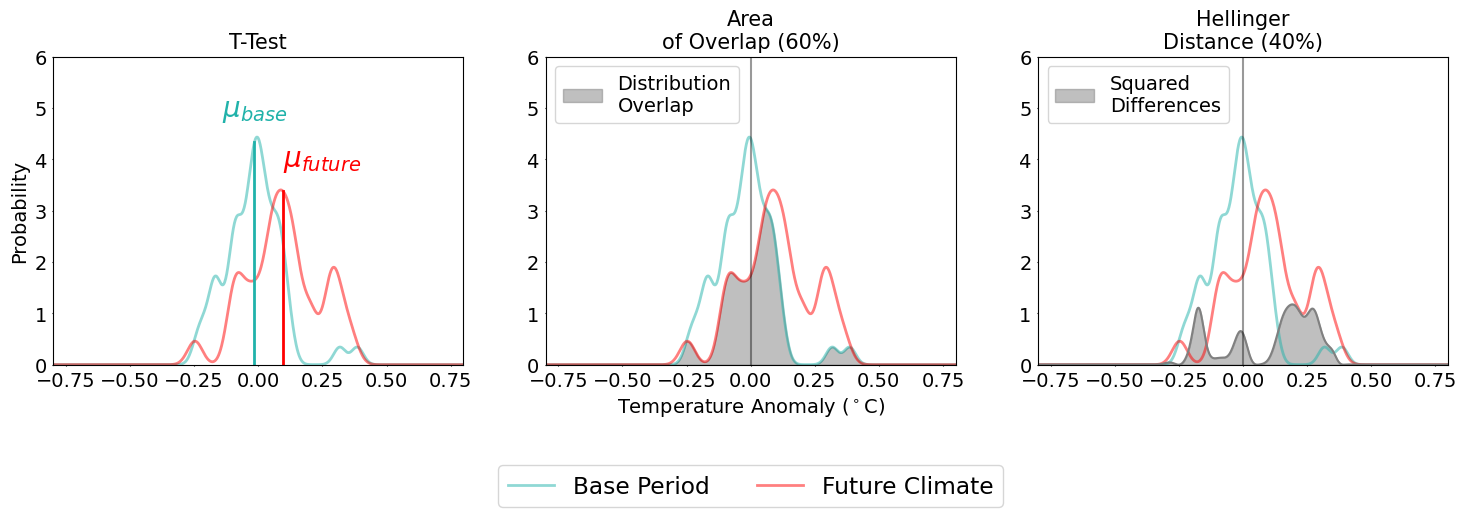

In [231]:

fig = plt.figure(figsize=(17, 22))
n_rows = 3  
gs = gridspec.GridSpec(n_rows, 2, height_ratios = [1, 0.8, 0.6], hspace=0.45)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

subgrid = gs[2, :].subgridspec(1, 3)
lower_axes = [fig.add_subplot(subgrid[i]) for i in range(3)]

axes = [ax1, ax2, ax3, *lower_axes]

plot_gmst_and_toe(fig, ax1)
sn_ratio_figure_v2(fig, ax2)
ks_emergence_year = int(toe_ds['ks'].values.item())
fig, ax = ks_test_figure_v2(
    base_data=data_ds_smean,
    base_period=base_period_tuple,
    emergence_year=ks_emergence_year,
    fig=fig, ax=ax3
)
# ks_test_figure_v2(fig, ax3)
lower_pannels(fig, *lower_axes)

for i, ax in enumerate(axes): 
    ax.annotate(f'{chr(97+i)})', xy=(0.01 if i != 4 else -0.035, 1.03),
                xycoords='axes fraction', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])


In [232]:
colors = [
    'chocolate', 'hotpink', 'lightseagreen', 'blueviolet', 'goldenrod', 'lightslategray', 'tomato', 'green'] 

In [233]:
def plot_gmst_and_toe(fig=None, ax=None):
    main_metrics = ['PSS', 'KS', 'Mean', 'ens']
    if fig is None and ax is None:
        fig = plt.figure(figsize=(12, 6))
        ax = fig.add_subplot(111)
    time = data_ds_smean.time.dt.year.values
    arr = data_ds_smean.values
    if ensemble_dim in data_ds_smean_ens.dims and data_ds_smean_ens.sizes.get(ensemble_dim, 1) > 1:
        for member_i in range(data_ds_smean_ens.sizes[ensemble_dim]):
            ax.plot(time, data_ds_smean_ens.isel({ensemble_dim: member_i}).values, color='gray', alpha=0.08, linewidth=0.8)
    ax.plot(time, arr, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], color='black', label='Ensemble median')
    for i, (year, toe_metrics) in enumerate(toe_labels.items()):
        colour = colors[i % len(colors)]
        if not any(mm in toe_metrics for mm in main_metrics):
            line_format_dict = dict(linestyle='-', alpha=0.5, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'] + 0.5)
        else:
            line_format_dict = dict(linestyle='-', alpha=1, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'] + 0.5)
        final_label = toe_metrics
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.35, yval], color=colour, label=final_label, **line_format_dict)
        ax.scatter([year], [yval], color=colour, s=50, zorder=100)
    leg = ax.legend(fontsize=SHCEMATIC_FIGURE_DICT['labels'], labelspacing=0.2, handletextpad=0.2, loc='upper left', ncol=2)
    leg.set_title('Method')
    leg.get_title().set_fontsize(SHCEMATIC_FIGURE_DICT['labels'])
    ylower = ax.get_ylim()[0]
    base_box_kwargs = dict(linewidth=3, color=SHCEMATIC_FIGURE_DICT['base_color'])
    ax.plot([base_period_tuple[0], base_period_tuple[0]], [ylower, 0.5], **base_box_kwargs)
    ax.plot([base_period_tuple[-1], base_period_tuple[-1]], [ylower, 0.5], **base_box_kwargs)
    end_year = int(data_ds_smean.time.dt.year.max())
    ax.plot([base_period_tuple[0], end_year], [0, 0], linestyle='--', **base_box_kwargs)
    ax.plot([base_period_tuple[0], base_period_tuple[-1]], [ylower, ylower], **base_box_kwargs)
    ax.plot([base_period_tuple[0], base_period_tuple[-1]], [0.5, 0.5], **base_box_kwargs)
    ax.annotate('Base Period', xy=(np.mean(base_period_tuple), 0.53), fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'], ha='center', color=SHCEMATIC_FIGURE_DICT['base_color'])
    ax.set_ylabel(r'GMST Anomaly ($^\circ$ C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    format_timeseries_ax(ax)
    change_tick_size(ax, tick_size=8)
    ax.set_ylim(-0.35, 1.5)


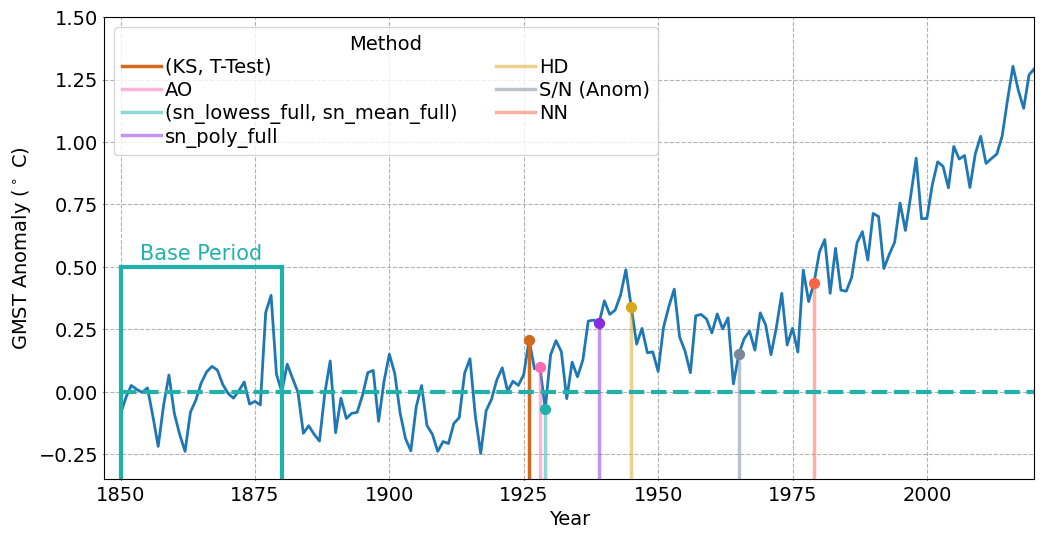

In [234]:
plot_gmst_and_toe()

1926

In [257]:
ks_emergence_year = int(toe_ds['ks'].values.item())
ks_emergence_year

1926

In [260]:
data_ds_smean.sel(time=slice(f'{ks_emergence_year-10}', f'{ks_emergence_year+10}'))

<xarray.DataArray 'temperature' (time: 21)> Size: 168B
-0.09818 -0.247 -0.07633 -0.03021 0.04842 ... -0.02745 0.1187 0.06004 0.1272
Coordinates:
  * time     (time) object 168B 1916-12-31 00:00:00 ... 1936-12-31 00:00:00

In [268]:
def ks_test_figure_v2(
    base_data: xr.DataArray,
    base_period: Tuple[int, int],
    emergence_year: int,
    emergence_window: int = 10,
    fig: Optional[Figure] = None,
    ax: Optional[Axes] = None,
) -> Tuple[Figure, Axes]:
    """Plot KS test comparing base period to emergence period CDFs.
    
    Parameters
    ----------
    base_data : xr.DataArray
        Time series data with 'time' coordinate
    base_period : Tuple[int, int]
        Start and end years of base period
    emergence_year : int
        Central year of emergence period
    emergence_window : int, optional
        Half-width of emergence period window (default: 10 years)
    fig, ax : optional
        Existing figure and axes to plot on
    """
    
    if fig is None or ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Get data for both periods
    base_array = base_data.sel(
        time=slice(str(base_period[0]), str(base_period[1]))
    ).values
    
    emergence_array = base_data.sel(
        time=slice(f'{emergence_year - emergence_window}', 
                   f'{emergence_year + emergence_window}')
    ).values
    
    # Calculate ECDFs
    ecdf_base = ECDF(base_array)
    ecdf_emergence = ECDF(emergence_array)
    
    # KS test
    ks_result = ks_2samp(base_array, emergence_array)
    
    # Plot CDFs
    ax.plot(ecdf_base.x, ecdf_base.y, 
            color=SHCEMATIC_FIGURE_DICT['base_color'],
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], 
            label='CDF of Base Period')
    
    ax.plot(ecdf_emergence.x, ecdf_emergence.y,
            color=SHCEMATIC_FIGURE_DICT['future_color'],
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'],
            label='CDF at Emergence')
    
    # Plot max KS statistic location
    x_values = np.unique(np.concatenate((ecdf_base.x, ecdf_emergence.x)))
    y_distances = np.abs(ecdf_base(x_values) - ecdf_emergence(x_values))
    max_idx = np.argmax(y_distances)
    # Plot max KS statistic location
    # Use the statistic_location from ks_result directly
    max_x = ks_result.statistic_location
    
    # Get the actual CDF values at this location
    max_y_base = ecdf_base(max_x)
    max_y_emergence = ecdf_emergence(max_x)
    
    print(f"max_x: {max_x}, max_y_base: {max_y_base}, max_y_emergence: {max_y_emergence}")
    
    ax.plot([max_x, max_x], [max_y_base, max_y_emergence+0.05],
            color='k', linestyle='--', linewidth=1.5,
            label=f'Max KS Statistic (D = {ks_result.statistic:.2f})')
    ax.scatter([max_x], [max_y_base], 
               color=SHCEMATIC_FIGURE_DICT['base_color'], s=50, zorder=1000)
    ax.scatter([max_x], [max_y_emergence+0.05], 
               color=SHCEMATIC_FIGURE_DICT['future_color'], s=50, zorder=1000)
    
    # Formatting
    ax.set_ylabel('Cumulative Density', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax.set_xlabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax.grid(True, linestyle='--', color='grey', alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim(0, 1.02)
    ax.set_title('Kolmogorov-Smirnov Test', 
                 fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])
    change_tick_size(ax, tick_size=8)
    
    return fig, ax

max_x: 0.039335206151008606, max_y_base: 0.7741935483870968, max_y_emergence: 0.38095238095238093


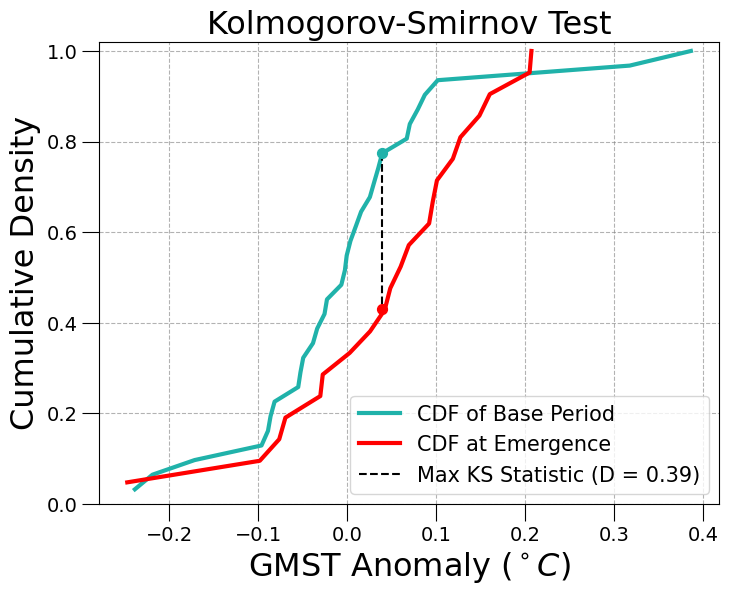

In [270]:
ks_emergence_year = int(toe_ds['ks'].values.item())
fig, ax = ks_test_figure_v2(
    base_data=data_ds_smean,
    base_period=base_period_tuple,
    emergence_year=ks_emergence_year
)

In [271]:
def sn_ratio_figure_v2(
    fig: Optional[Figure] = None,
    ax2: Optional[Axes] = None,
    fontscale: float = 1,
) -> Tuple[Figure, Axes, Axes]:

    if fig is None or ax2 is None:
        fig, ax2 = plt.subplots(1, 1, figsize=(8, 6))

    sn_vars = ['sn_lowess_full', 'sn_mean_full', 'sn_poly_full', 'sn_anom', 'sn_ens_med_full']
    sn_vars = [sn_name for sn_name in sn_vars if sn_name in toe_metrics_ds.data_vars]
    colors_here = np.take(colors, [1, 2, 3, 5, 0], mode='wrap')

    for i, sn_name in enumerate(sn_vars):
        alpha = 0.35 if sn_name == 'sn_anom' else 1
        ax2.plot(
            toe_metrics_ds.time.dt.year.values,
            toe_metrics_ds[sn_name].values,
            color=colors_here[i],
            label=toe_const.NAME_CONVERSION_DICT_SHORT.get(sn_name, sn_name),
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'],
            alpha=alpha
        )

    ax2.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])
    format_timeseries_ax(ax2)
    xpost_label = int(data_ds_smean.time.dt.year.min()) + 1
    frame_lines = dict(linestyle='--', color='red')
    ax2.axhline(1, **frame_lines)
    ax2.annotate('Unusual', xy=(xpost_label, 1), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(2, **frame_lines)
    ax2.annotate('Unfamiliar', xy=(xpost_label, 2), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(3, **frame_lines)
    ax2.annotate('Unknown', xy=(xpost_label, 3), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(5, **frame_lines)
    ax2.annotate('Inconceivable', xy=(xpost_label, 5), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.set_ylabel('S/N Ratio', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax2.set_title('Signal-to-noise (S/N) Ratio', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    change_tick_size(ax2, tick_size=8)

    return fig, ax2


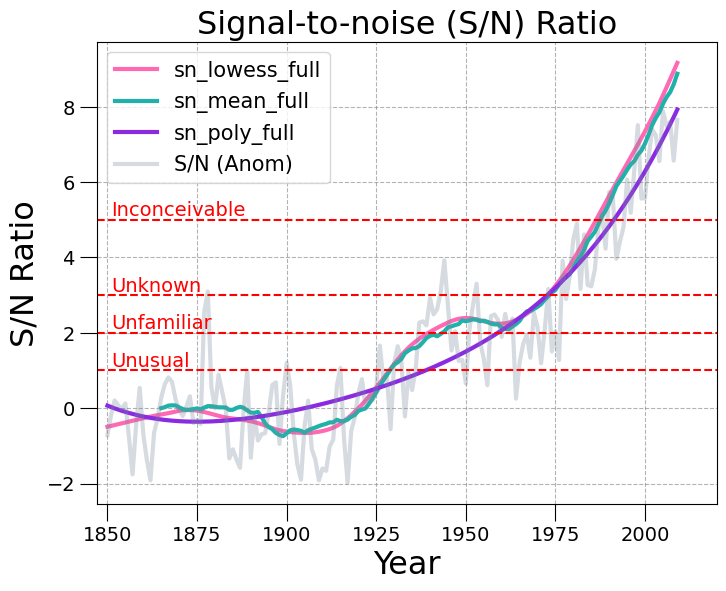

In [272]:
sn_ratio_figure_v2()

In [ ]:
def probability_ratio_figure_v2(
    data_ens: Optional[xr.DataArray] = None,
    base_period: Tuple[int, int] = base_period_tuple,
    event_quantile: float = 0.95,
    rolling_window: int = 30,
    fig: Optional[Figure] = None,
    ax_prob: Optional[Axes] = None,
    ax_pr: Optional[Axes] = None,
) -> Tuple[Figure, Axes, Axes, xr.DataArray]:
    """Demonstration plot for Probability Ratio (PR) using ensemble exceedance rates.

    Event definition: GMST anomaly > base-period q-quantile.
    PR(t) = p1(t) / p0, where p1 is rolling event probability and
    p0 is base-period event probability.
    """

    if data_ens is None:
        data_ens = data_ds_smean_ens

    ens_dims = []
    if ensemble_dim in data_ens.dims and data_ens.sizes.get(ensemble_dim, 1) > 1:
        ens_dims = [ensemble_dim]

    base_slice = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    q_dims = ['time'] + ens_dims
    event_threshold = float(base_slice.quantile(event_quantile, dim=q_dims).values.item())

    event_da = xr.where(data_ens > event_threshold, 1.0, 0.0)

    base_event = event_da.sel(time=slice(str(base_period[0]), str(base_period[1])))
    p0 = float(base_event.mean(dim=q_dims).values.item())
    p0_safe = max(p0, 1e-6)

    p1 = event_da.rolling(time=rolling_window, center=True).mean()
    if ens_dims:
        p1 = p1.mean(dim=ens_dims)

    pr_da = p1 / p0_safe

    if fig is None or ax_prob is None or ax_pr is None:
        fig, (ax_prob, ax_pr) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    years = pr_da.time.dt.year.values

    ax_prob.plot(years, p1.values, color='tab:blue', linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='Rolling event probability $p_1(t)$')
    ax_prob.axhline(p0, color='tab:orange', linestyle='--', linewidth=2, label=f'Base probability $p_0$ = {p0:.3f}')
    ax_prob.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_prob.set_title('Event Probability: Base vs Rolling', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax_prob.grid(True, linestyle='--', alpha=0.5)
    ax_prob.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])

    ax_pr.plot(years, pr_da.values, color='tab:purple', linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='PR = $p_1(t)/p_0$')
    ax_pr.axhline(1, color='red', linestyle='--', linewidth=1.8)
    ax_pr.axhline(2, color='red', linestyle=':', linewidth=1.5)
    ax_pr.annotate('No change (PR=1)', xy=(years[5], 1.02), color='red', fontsize=SHCEMATIC_FIGURE_DICT['other_text'])
    ax_pr.annotate('PR=2', xy=(years[5], 2.05), color='red', fontsize=SHCEMATIC_FIGURE_DICT['other_text'])
    ax_pr.set_ylabel('Probability Ratio', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_pr.set_xlabel('Year', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_pr.set_title('Probability Ratio Demonstration', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax_pr.grid(True, linestyle='--', alpha=0.5)
    ax_pr.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])

    for ax in [ax_prob, ax_pr]:
        format_timeseries_ax(ax)
        change_tick_size(ax, tick_size=8)

    return fig, ax_prob, ax_pr, pr_da


In [ ]:
fig, ax_prob, ax_pr, pr_ds = probability_ratio_figure_v2()


In [273]:
SHCEMATIC_FIGURE_DICT = {
    'base_color': 'lightseagreen',
    'future_color': 'red', 
    'title_fontsize': 23, #15
    'other_text': 14, #10
    'labels': 23, #15
    'legend_elements': 15, 
    'tick_size': 12,
    'linewidth': 3 #2
}

max_x: 0.039335206151008606, max_y_base: 0.7741935483870968, max_y_emergence: 0.38095238095238093


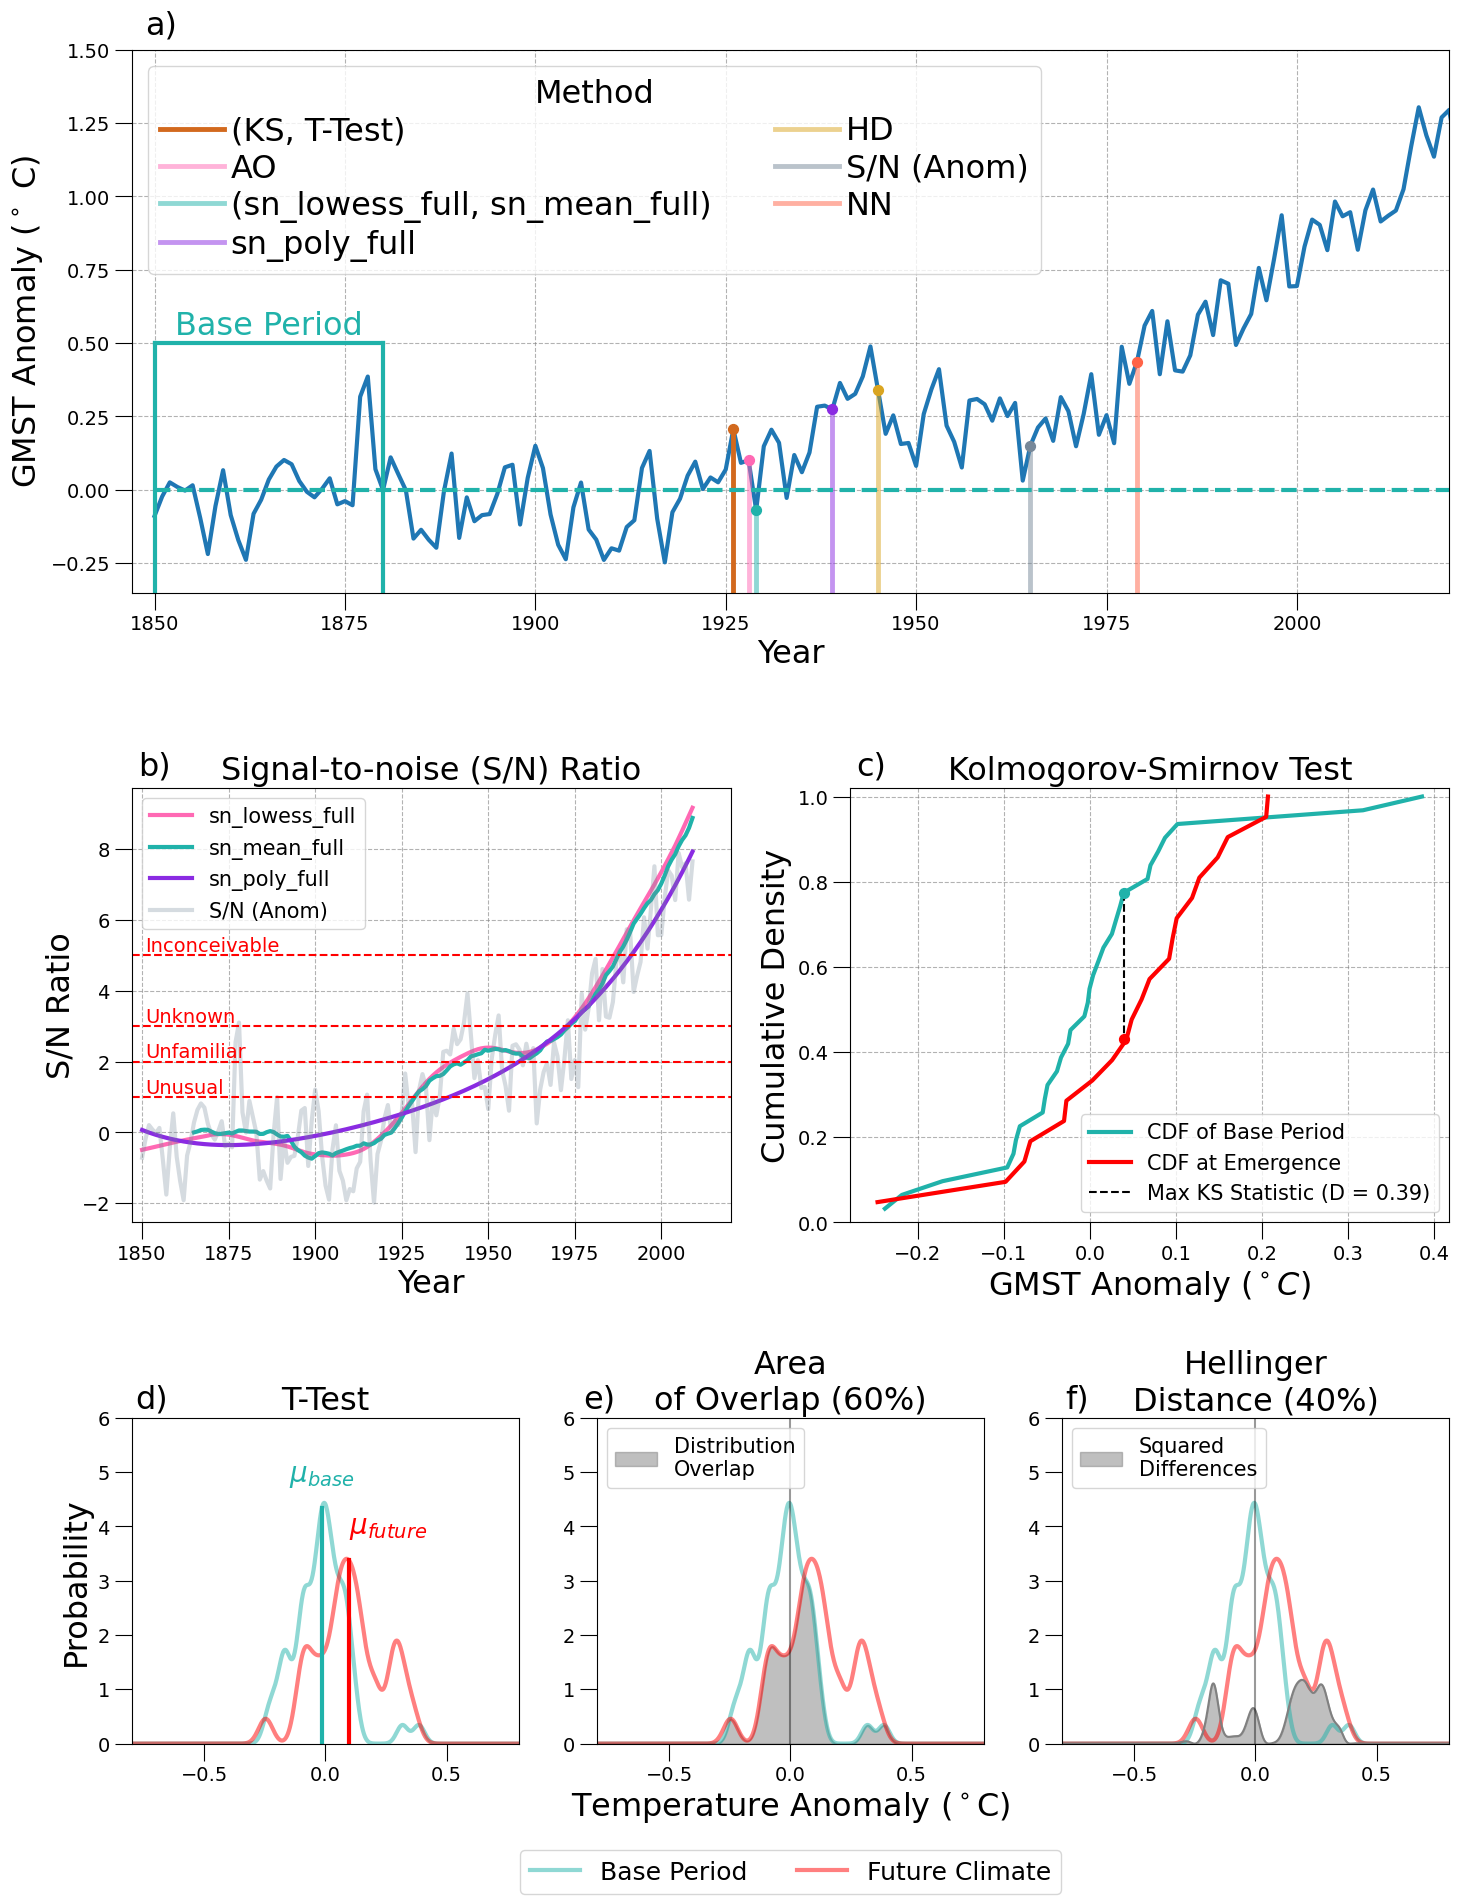

In [275]:
fig = plt.figure(figsize=(17, 22))
n_rows = 3  
gs = gridspec.GridSpec(n_rows, 2, height_ratios = [1, 0.8, 0.6], hspace=0.45)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

subgrid = gs[2, :].subgridspec(1, 3)
lower_axes = [fig.add_subplot(subgrid[i]) for i in range(3)]

axes = [ax1, ax2, ax3, *lower_axes]

plot_gmst_and_toe(fig, ax1)
sn_ratio_figure_v2(fig, ax2)
ks_emergence_year = int(toe_ds['ks'].values.item())
fig, ax = ks_test_figure_v2(
    base_data=data_ds_smean,
    base_period=base_period_tuple,
    emergence_year=ks_emergence_year,
    fig=fig, ax=ax3
)
# ks_test_figure_v2(fig, ax3)
lower_pannels(fig, *lower_axes)

for i, ax in enumerate(axes): 
    ax.annotate(f'{chr(97+i)})', xy=(0.01 if i != 4 else -0.035, 1.03),
                xycoords='axes fraction', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])

### Old

In [ ]:
def overlap_figure(
    fig: Optional[Figure] = None,
    ax1: Optional[Axes] = None,
    ax2: Optional[Axes] = None,
    ax3: Optional[Axes] = None
) -> Tuple[Figure, Axes, Axes, Axes]:
    
    if fig is None or ax1 is None or ax2 is None:
        fig = plt.figure(figsize=(18, 4))
        ax1 = fig.add_subplot(131)
        ax2 = fig.add_subplot(132)
        ax3 = fig.add_subplot(133)

    axes = [ax1, ax2, ax3]

    for ax in axes:
        ax.axvline(0, color='k', alpha=0.4)

    start_year = int(data_ds_smean.time.dt.year.values[0])
    base_arr = data_ds_smean.isel(time=slice(0, 50))
    
    fgs_emergence_year = 1928
    # This will be the arguement for the start of the 30 year base period 
    # 
    start_arr = fgs_emergence_year - start_year - 15# + 4
    # print(start_arr)

    arr = data_ds_smean.isel(time=slice(start_arr, start_arr+30)).values
    
    num_bins = 25
    
    bmax = 0.6#np.nanmax(np.concatenate([base_arr, arr]))*1.2
    bmin = -0.6#np.nanmin(np.concatenate([base_arr, arr]))*1.2
    
    
    # Define the bin width and create bin edges
    bins = np.linspace(bmin, bmax, num_bins)
    
    _, pdf_base = toe.discrete_pdf(base_arr, bins)
    _, pdf_arr = toe.discrete_pdf(arr, bins)
    
    pps_overlap = toe.discrete_distribution_overlap(pdf_base, pdf_arr)
    
    x_kde, kde_vals2, kde_vals1, fga_overlap = toe.fractional_geometric_area(
        base_arr, arr, return_all=True, method_kwargs=dict(bw_method=0.2), bmin=bmin, bmax=bmax)#'silverman'))

    
    ax1.bar(bins[:-1], pdf_base, width=np.diff(bins), align='edge', label='Base Period',
           color=SHCEMATIC_FIGURE_DICT['base_color'], alpha=0.5, edgecolor='k')
    ax1.bar(bins[:-1], pdf_arr, width=np.diff(bins), align='edge', label='Future Climate',
           color=SHCEMATIC_FIGURE_DICT['future_color'], alpha=0.5, edgecolor='k')
    
    
    ### FGA
    ax2.plot(x_kde, kde_vals1, color=SHCEMATIC_FIGURE_DICT['base_color'], #label='Base Period', 
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    ax2.plot(x_kde, kde_vals2, color=SHCEMATIC_FIGURE_DICT['future_color'],# label='Future Climate',
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    ax2.fill_between(x_kde, 0, np.min(np.vstack([kde_vals1, kde_vals2]), axis=0),
                     color='gray', alpha=0.3, label='Distribution\nOverlap')
    
    #### Hellinger Distance
    squared_diff = (np.sqrt(kde_vals1) - np.sqrt(kde_vals2))**2
    hellinger_distance = np.sqrt(np.sum(squared_diff) * (x_kde[1] - x_kde[0])) / np.sqrt(2)
    
    # Plot the original distributions
    ax3.plot(x_kde, kde_vals1, #label=f'Base Period',
             color=SHCEMATIC_FIGURE_DICT['base_color'],
             linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    ax3.plot(x_kde, kde_vals2, #label=f'Test Period',
             color=SHCEMATIC_FIGURE_DICT['future_color'],
             linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    
    
    #ax3Fill the area under the squared differences
    plt.fill_between(x_kde, 0, squared_diff, color='gray', alpha=0.3,
                     label=f'Squared\nDifferences')
    
    # Add titles and labels
    for ax in axes:
        change_tick_size(ax)
        ax.set_xlim(-0.8, 0.8)
        ax.set_ylim(0, None)
    ax2.set_xlabel(r'Temperature Anomaly ($^\circ$C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])

    ax1.set_ylabel('Relative Frequency', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax2.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax3.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    
    ax1.set_title(f'Perkins\nSkill Score ({pps_overlap:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax2.set_title(f'Area\nof Overlap ({fga_overlap:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax3.set_title(f'Hellinger\nDistance ({hellinger_distance*100:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    bbox_to_anchor = (1.7, -0.42)
    ax1.legend(loc='lower center', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'] *1.2, ncol=2,
               bbox_to_anchor=bbox_to_anchor)
    ax2.legend(loc='upper left', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'], ncol=2)#bbox_to_anchor=bbox_to_anchor)
    ax3.legend(loc='upper left', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'], ncol=2) #bbox_to_anchor=bbox_to_anchor)

In [ ]:
def overlap_figure_v2(
    fig: Optional[Figure] = None,
    ax1: Optional[Axes] = None,
    ax2: Optional[Axes] = None,
) -> Tuple[Figure, Axes, Axes, Axes]:
    
    if fig is None or ax1 is None or ax2 is None:
        fig = plt.figure(figsize=(12, 3))
        ax1 = fig.add_subplot(131)
        ax2 = fig.add_subplot(132)

    axes = [ax1, ax2]
    ax3 = ax2

    for ax in axes:
        ax.axvline(0, color='k', alpha=0.4)

    start_year = int(data_ds_smean.time.dt.year.values[0])
    base_arr = data_ds_smean.isel(time=slice(0, 50))
    
    fgs_emergence_year = 1928
    # This will be the arguement for the start of the 30 year base period 
    # 
    start_arr = fgs_emergence_year - start_year - 15# + 4
    # print(start_arr)

    arr = data_ds_smean.isel(time=slice(start_arr, start_arr+30)).values
    
    num_bins = 25
    
    bmax = 0.6#np.nanmax(np.concatenate([base_arr, arr]))*1.2
    bmin = -0.6#np.nanmin(np.concatenate([base_arr, arr]))*1.2
    
    
    # Define the bin width and create bin edges
    bins = np.linspace(bmin, bmax, num_bins)
    
    _, pdf_base = toe.discrete_pdf(base_arr, bins)
    _, pdf_arr = toe.discrete_pdf(arr, bins)
    
    pps_overlap = toe.discrete_distribution_overlap(pdf_base, pdf_arr)
    
    x_kde, kde_vals2, kde_vals1, fga_overlap = toe.fractional_geometric_area(
        base_arr, arr, return_all=True, method_kwargs=dict(bw_method=0.2), bmin=bmin, bmax=bmax)#'silverman'))

    
    ax1.bar(bins[:-1], pdf_base, width=np.diff(bins), align='edge', label='Base Period',
           color=SHCEMATIC_FIGURE_DICT['base_color'], alpha=0.5, edgecolor='k')
    ax1.bar(bins[:-1], pdf_arr, width=np.diff(bins), align='edge', label='Base Period',
           color=SHCEMATIC_FIGURE_DICT['future_color'], alpha=0.5, edgecolor='k')
    
    
    ### FGA
    ax2.plot(x_kde, kde_vals1, color=SHCEMATIC_FIGURE_DICT['base_color'], label='Base Period', 
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    ax2.plot(x_kde, kde_vals2, color=SHCEMATIC_FIGURE_DICT['future_color'], label='Future Climate',
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    ax2.fill_between(x_kde, 0, np.min(np.vstack([kde_vals1, kde_vals2]), axis=0),
                     color='gray', alpha=0.3)
    
    #### Hellinger Distance
    squared_diff = (np.sqrt(kde_vals1) - np.sqrt(kde_vals2))**2
    hellinger_distance = np.sqrt(np.sum(squared_diff) * (x_kde[1] - x_kde[0])) / np.sqrt(2)
    
    # Plot the original distributions
    # ax3.plot(x_kde, kde_vals1, label=f'Base Period', color=SHCEMATIC_FIGURE_DICT['base_color'],
    #          linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    # ax3.plot(x_kde, kde_vals2, label=f'Test Period', color=SHCEMATIC_FIGURE_DICT['future_color'],
    #          linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    
    
    #ax3Fill the area under the squared differences
    plt.fill_between(x_kde, 0, squared_diff, color='blue', alpha=0.3,
                     label=f'Squared Differences')
    
    # Add titles and labels
    for ax in axes:
        change_tick_size(ax)
        ax.set_xlim(-0.6, 0.6)
        ax.set_ylim(0, None)
    ax2.set_xlabel(r'Temperature Anomaly ($^\circ$C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])

    ax1.set_ylabel('Relative Frequency', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax2.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    # ax3.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    
    ax1.set_title(f'Perkins Skill Score ({pps_overlap:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax2.set_title(f'Area of Overlap ({fga_overlap:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    # ax3.set_title(f'Hellinger Distance ({hellinger_distance*100:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    
    ax2.legend(loc='lower center', fontsize=SHCEMATIC_FIGURE_DICT['other_text'], ncol=2, bbox_to_anchor=(0.5, -0.5))

In [316]:

def sn_ratio_figure(
    fig: Optional[Figure] = None,
    ax1: Optional[Axes] = None,
    ax2: Optional[Axes] = None
) -> Tuple[Figure, Axes, Axes]:
    
    if fig is None or ax1 is None or ax2 is None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))
    
    ### Upper aes
    time = ds_data_lowess.time.dt.year.values
    ax1.plot(time, data_ds_smean.values, linewidth=3, label='GMST')
    ax1.plot(time, ds_data_lowess.values, linewidth=3, label='LOWESS')
    
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('GMST Anomaly', fontsize=22)
    ax1.set_xlabel('Year', fontsize=22)
    ax1.grid(True)
    
    ylower = ax1.get_ylim()[0]
    ax1.plot([1850, 1850], [ylower, 0.5], linewidth=3, color='green')
    ax1.plot([1900, 1900], [ylower, 0.5], linewidth=3, color='green')
    ax1.plot([1850, 2025], [0, 0], color='green', linewidth=3, linestyle='--')
    # ax1.plot([1850, 1900], [0, 0], color='green', linewidth=5)
    ax1.plot([1850, 1900], [ylower, ylower], color='green', linewidth=5)
    ax1.plot([1850, 1900], [0.5, 0.5], color='green', linewidth=5)
    
    
    itime = 135
    ax1.scatter(time[itime], ds_data_lowess.values[itime], marker='o', s=150,
              color='red')
    ax1.plot([time[itime], time[itime]], [0, ds_data_lowess.values[itime]],
           color='red', linewidth=3, linestyle='--')
    
    ax1.annotate('Signal', xy=(time[itime]+2, ds_data_lowess.values[itime]/2), fontsize=20, ha='left', 
                color='red', va='center')
    
    ax1.set_ylim(ylower, 1.55)
    ax1.annotate('Base Period', xy=(1875, 0.53), fontsize=20, ha='center', color='green')
    
    ax1.set_xlim(1848, 2025)
    
    
    
    ### Lower axes
    
    time = ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].time.dt.year.values
    ax2.plot(time, ds_data_sn_multi.loc[{'method':'sn_lowess_full'}].values, linewidth=3)
    
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_ylabel('S/N Ratio', fontsize=22)
    ax2.set_xlabel('Year', fontsize=22)
    ax2.grid(True)
    
    
    ax2.set_xlim(1848, 2025)
    
    
    frame_lines = dict(linestyle='--', color='red')
    ax2.axhline(1, **frame_lines)
    ax2.annotate('Unusual', xy=(1861, 1), va='bottom', size=15, color='red')
    ax2.axhline(2, **frame_lines)
    ax2.annotate('Unfamiliar', xy=(1861, 2), va='bottom', size=15, color='red')
    ax2.axhline(3, **frame_lines)
    ax2.annotate('Unknown', xy=(1861, 3), va='bottom', size=15, color='red')
    
    ax2.axhline(5, **frame_lines)
    ax2.annotate('Inconceivable', xy=(1861, 5), va='bottom', size=15, color='red')
    
    ax1.legend()

In [317]:
def ks_test_figure(
    fig: Optional[Figure] = None,
    ax: Optional[Axes] = None,
    ax2: Optional[Axes] = None
) -> Tuple[Figure, Axes, Axes]:
    
    if fig is None or ax1 is None or ax2 is None:
        fig, (ax2, ax) = plt.subplots(1, 2, figsize=(16, 6))
        
    # Assuming ks_emergence_year and base_period_tuple are already defined
    ks_emergence_year = int(toe_ds['ks'].values.item())
    base_period_end = base_period_tuple[-1]
    year_until_emergence = ks_emergence_year - base_period_end
    years = np.arange(0, 40, 3) # These are the years after the base period
    # The central year will be the end of the base period + 10 (ass middle of 20-years), +year
    central_years = base_period_end+10+years
    years, central_years
    
    # Set up your plot
    
    ax2.plot(data_ds_smean.time.dt.year.values, data_ds_smean.values)
    # Green base period annotations
    ylower = ax2.get_ylim()[0]
    upper_box = 0.45
    box_line_width = 3
    ax2.plot([1850, 1850], [ylower+0.05, upper_box], linewidth=box_line_width, color='green')
    ax2.plot([1900, 1900], [ylower+0.05, upper_box], linewidth=box_line_width, color='green')
    # ax2.plot([1850, 2025], [0, 0], color='green', linewidth=2, linestyle='--')
    # ax2.plot([1850, 1900], [0, 0], color='green', linewidth=2)
    ax2.plot([1850, 1900], [ylower+0.05, ylower+0.05], color='green', linewidth=box_line_width)
    ax2.plot([1850, 1900], [upper_box, upper_box], color='green', linewidth=box_line_width)
    
    ax2.annotate('Base Period', xy=(1875, 0.5), fontsize=22, ha='center', color='green')
    
    ax2.set_xlim(1849, 1960)
    ax2.grid(True, which='both', linestyle='--', color='grey', alpha=0.7)
    
    # Base array for comparison
    base_array = data_ds_smean.isel(time=slice(0, 50)).values  # Length 50
    ecdf_base = ECDF(base_array)
    ax.plot(ecdf_base.x, ecdf_base.y, color='green', linewidth=3, label='1850-1900\n(Base Period)')
    
    # Prepare to calculate KS statistics and p-values
    ks_statistics = []
    ks_statistics2 = []
    
    p_values = []
    
    # Set up color maps
    cmap1 = cm.get_cmap('Blues', sum(central_years < ks_emergence_year) + 3)  
    cmap2 = cm.get_cmap('Reds', sum(central_years >= ks_emergence_year) + 3) 
    
    # Loop through the years and calculate ECDFs, KS statistics, and p-values
    count = 3
    for year, central_year in zip(years, central_years):
    
        data2 = data_ds_smean.values[50 + year:70 + year]  # Second dataset (length 20)
        ecdf2 = ECDF(data2)
        
    
        # Compute KS statistic and p-value using ks_2samp
        ks_statistic2, p_value = ks_2samp(base_array, data2)  # Direct KS test
    
    
        # Get color from colormap
        if central_year < ks_emergence_year:
            color = cmap1(count)
            count += 1
        else:
            color = cmap2(count) 
            count += 1
    
            # Set line width based on conditions
        if ks_emergence_year - 3 < central_year < ks_emergence_year + 3:
            linewidth = 3
            count = 3
            linewidth_ax2 = 5
            color='magenta'
            
        else:
            color='green'
            linewidth = 1
            linewidth_ax2 = 2
    
        # Plot the ECDF for the second dataset
        if p_value < 0.01:
        #     p_value_str = '<0.01'
        # else:
        #     p_value_str = f'{p_value:.2f}'
    
            year_str = f'{central_year-10}-{central_year+10}'
            ax.plot(ecdf2.x, ecdf2.y, color=color,
                    label=f'{year_str} ({p_value_str})', linewidth=linewidth)
        
            data2_mean = np.nanmean(data2)
            ax2.plot([base_period_end + year, base_period_end+ 20 + year], [data2_mean, data2_mean],
                    color=color, linewidth=linewidth_ax2, alpha=0.85)
            break
    
    
    
    # Set labels, grid, and legend
    ax.set_ylabel('Cumulative Density', fontsize=22)
    ax.set_xlabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=22)
    ax2.set_ylabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=22)
    ax2.set_xlabel('Year', fontsize=22)
    
    ax.grid(True)
    # ax.legend(loc='right', bbox_to_anchor=[1.0, 0.35], fontsize=8)
    
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=20)
    ax2.tick_params(axis='y', labelsize=20)
    ax2.tick_params(axis='x', labelsize=20)
    
    ax.set_ylim(0, 1.02)
    
    ax2.set_ylim(-0.3, 0.75)
    
    ax2.set_title('GMST Time Series', fontsize=22)
    ax.set_title('CDFs', fontsize=22)

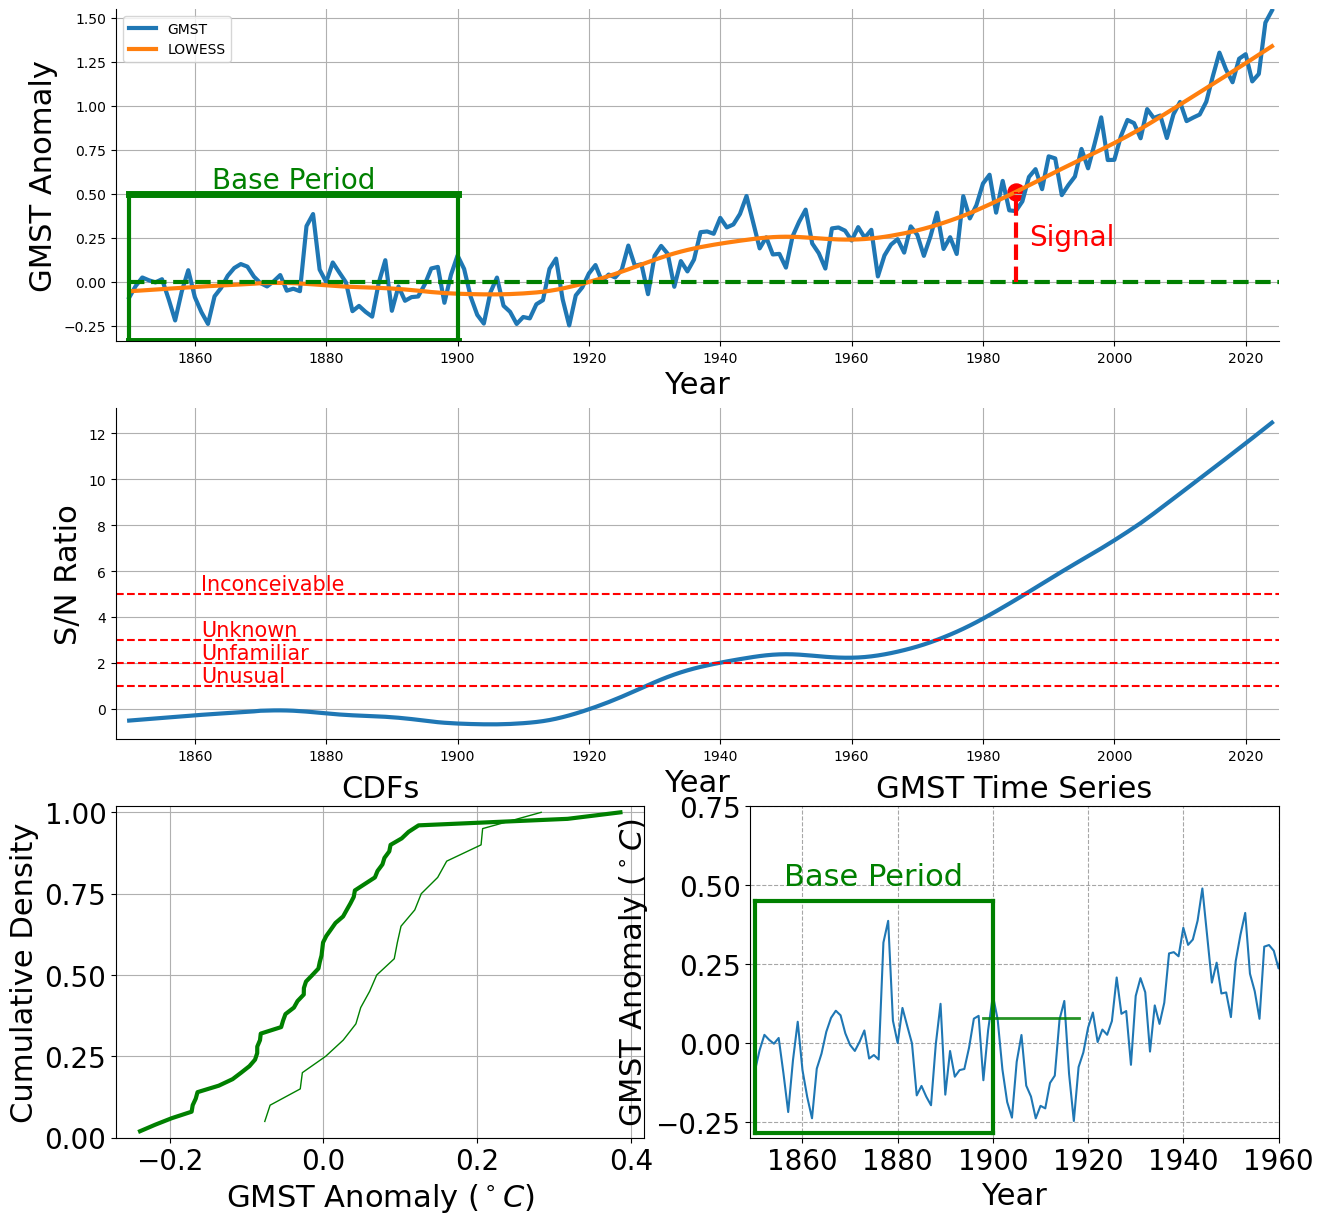

In [318]:
fig = plt.figure(figsize=(15, 25))
n_rows = 5
gs = gridspec.GridSpec(n_rows, 2)

sn_axes = [fig.add_subplot(gs[i, :]) for i in range(2)]
ks_axes = [fig.add_subplot(gs[2, i]) for i in range(2)]

sn_ratio_figure(fig, *sn_axes)
ks_test_figure(fig, *ks_axes)

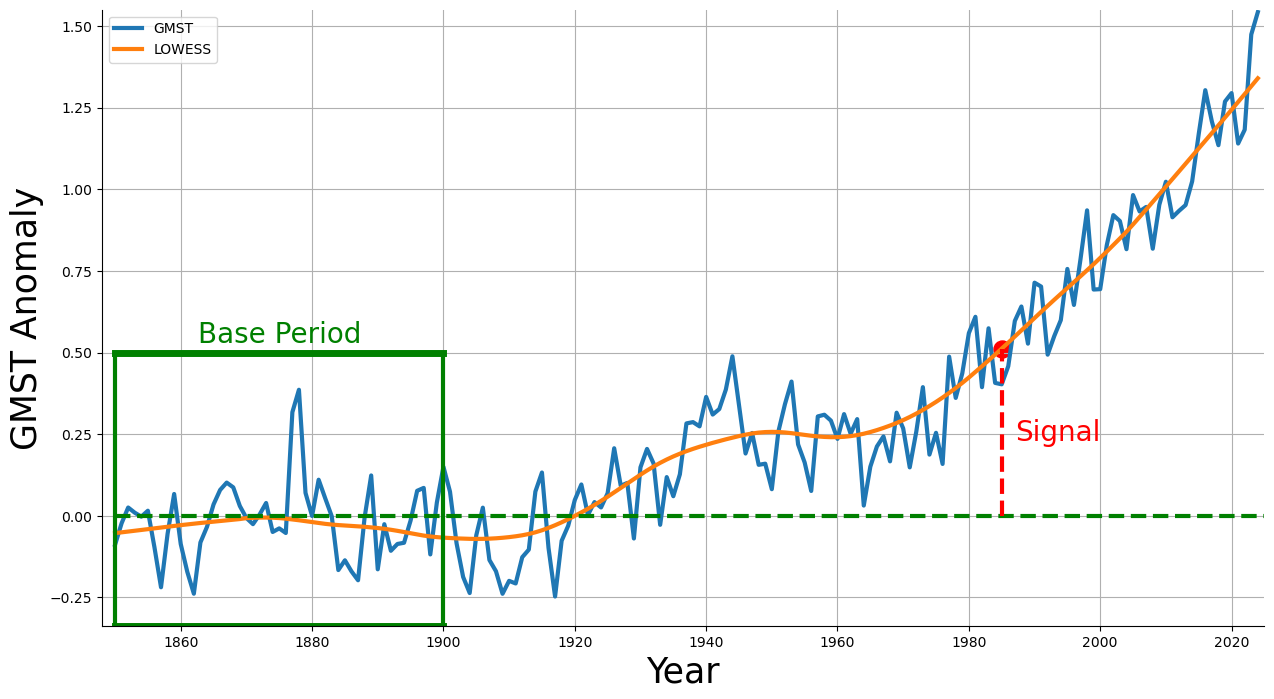

In [319]:

fig, ax1 = plt.subplots(1, 1, figsize=(15, 8))

### Upper aes
time = ds_data_lowess.time.dt.year.values
ax1.plot(time, data_ds_smean.values, linewidth=3, label='GMST')
ax1.plot(time, ds_data_lowess.values, linewidth=3, label='LOWESS')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylabel('GMST Anomaly', fontsize=25)
ax1.set_xlabel('Year', fontsize=25)
ax1.grid(True)

ylower = ax1.get_ylim()[0]
ax1.plot([1850, 1850], [ylower, 0.5], linewidth=3, color='green')
ax1.plot([1900, 1900], [ylower, 0.5], linewidth=3, color='green')
ax1.plot([1850, 2025], [0, 0], color='green', linewidth=3, linestyle='--')
# ax1.plot([1850, 1900], [0, 0], color='green', linewidth=5)
ax1.plot([1850, 1900], [ylower, ylower], color='green', linewidth=5)
ax1.plot([1850, 1900], [0.5, 0.5], color='green', linewidth=5)


itime = 135
ax1.scatter(time[itime], ds_data_lowess.values[itime], marker='o', s=150,
          color='red')
ax1.plot([time[itime], time[itime]], [0, ds_data_lowess.values[itime]],
       color='red', linewidth=3, linestyle='--')

ax1.annotate('Signal', xy=(time[itime]+2, ds_data_lowess.values[itime]/2), fontsize=20, ha='left', 
            color='red', va='center')

ax1.set_ylim(ylower, 1.55)
ax1.annotate('Base Period', xy=(1875, 0.53), fontsize=20, ha='center', color='green')

ax1.set_xlim(1848, 2025)

ax1.legend()

In [320]:
# Assuming ks_emergence_year and base_period_tuple are already defined
ks_emergence_year = int(toe_ds['ks'].values.item())
base_period_end = base_period_tuple[-1]
year_until_emergence = ks_emergence_year - base_period_end
years = np.arange(0, 40, 3) # These are the years after the base period
# The central year will be the end of the base period + 10 (ass middle of 20-years), +year
central_years = base_period_end+10+years
years, central_years

(array([ 0,  3,  6,  9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39]),
 array([1890, 1893, 1896, 1899, 1902, 1905, 1908, 1911, 1914, 1917, 1920,
        1923, 1926, 1929]))

Text(0.5, 1.0, 'CDFs')

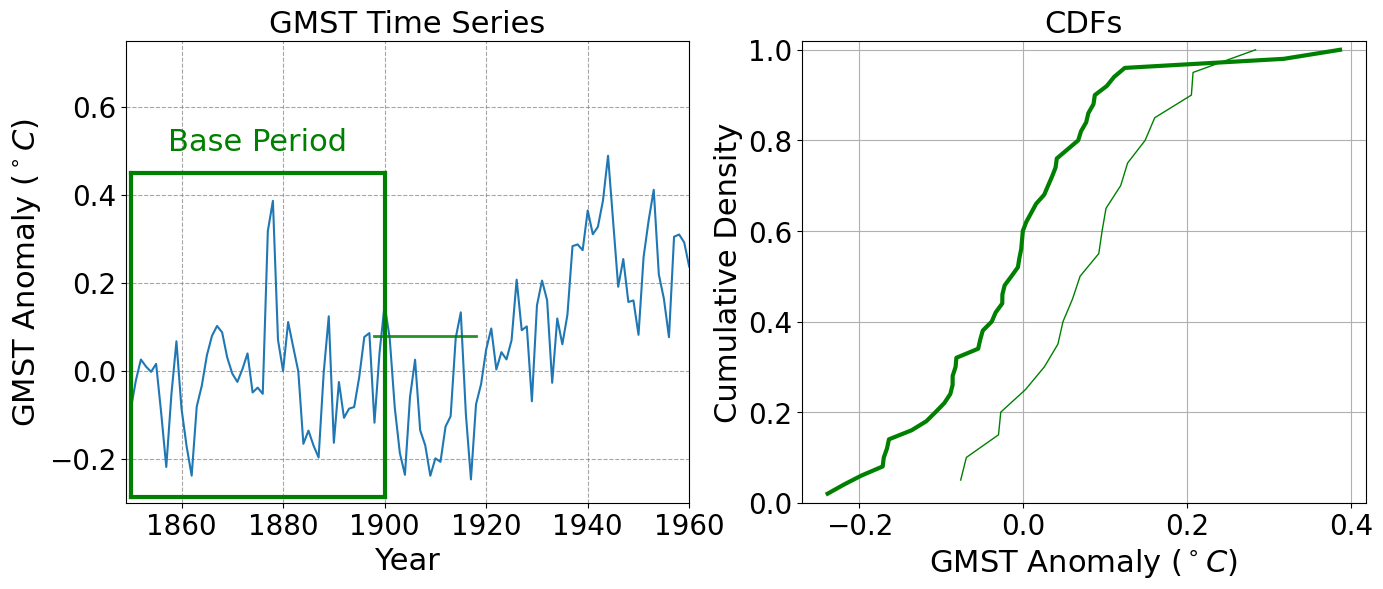

In [321]:
# Set up your plot
fig, (ax2, ax) = plt.subplots(1, 2, figsize=(16, 6))

ax2.plot(data_ds_smean.time.dt.year.values, data_ds_smean.values)
# Green base period annotations
ylower = ax2.get_ylim()[0]
upper_box = 0.45
box_line_width = 3
ax2.plot([1850, 1850], [ylower+0.05, upper_box], linewidth=box_line_width, color='green')
ax2.plot([1900, 1900], [ylower+0.05, upper_box], linewidth=box_line_width, color='green')
# ax2.plot([1850, 2025], [0, 0], color='green', linewidth=2, linestyle='--')
# ax2.plot([1850, 1900], [0, 0], color='green', linewidth=2)
ax2.plot([1850, 1900], [ylower+0.05, ylower+0.05], color='green', linewidth=box_line_width)
ax2.plot([1850, 1900], [upper_box, upper_box], color='green', linewidth=box_line_width)

ax2.annotate('Base Period', xy=(1875, 0.5), fontsize=22, ha='center', color='green')

ax2.set_xlim(1849, 1960)
ax2.grid(True, which='both', linestyle='--', color='grey', alpha=0.7)

# Base array for comparison
base_array = data_ds_smean.isel(time=slice(0, 50)).values  # Length 50
ecdf_base = ECDF(base_array)
ax.plot(ecdf_base.x, ecdf_base.y, color='green', linewidth=3, label='1850-1900\n(Base Period)')

# Prepare to calculate KS statistics and p-values
ks_statistics = []
ks_statistics2 = []

p_values = []

# Set up color maps
cmap1 = cm.get_cmap('Blues', sum(central_years < ks_emergence_year) + 3)  
cmap2 = cm.get_cmap('Reds', sum(central_years >= ks_emergence_year) + 3) 

# Loop through the years and calculate ECDFs, KS statistics, and p-values
count = 3
for year, central_year in zip(years, central_years):

    data2 = data_ds_smean.values[50 + year:70 + year]  # Second dataset (length 20)
    ecdf2 = ECDF(data2)
    

    # Compute KS statistic and p-value using ks_2samp
    ks_statistic2, p_value = ks_2samp(base_array, data2)  # Direct KS test


    # Get color from colormap
    if central_year < ks_emergence_year:
        color = cmap1(count)
        count += 1
    else:
        color = cmap2(count) 
        count += 1

        # Set line width based on conditions
    if ks_emergence_year - 3 < central_year < ks_emergence_year + 3:
        linewidth = 3
        count = 3
        linewidth_ax2 = 5
        color='magenta'
        
    else:
        color='green'
        linewidth = 1
        linewidth_ax2 = 2

    # Plot the ECDF for the second dataset
    if p_value < 0.01:
    #     p_value_str = '<0.01'
    # else:
    #     p_value_str = f'{p_value:.2f}'

        year_str = f'{central_year-10}-{central_year+10}'
        ax.plot(ecdf2.x, ecdf2.y, color=color,
                label=f'{year_str} ({p_value_str})', linewidth=linewidth)
    
        data2_mean = np.nanmean(data2)
        ax2.plot([base_period_end + year, base_period_end+ 20 + year], [data2_mean, data2_mean],
                color=color, linewidth=linewidth_ax2, alpha=0.85)
        break



# Set labels, grid, and legend
ax.set_ylabel('Cumulative Density', fontsize=22)
ax.set_xlabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=22)
ax2.set_ylabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=22)
ax2.set_xlabel('Year', fontsize=22)

ax.grid(True)
# ax.legend(loc='right', bbox_to_anchor=[1.0, 0.35], fontsize=8)

ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)
ax2.tick_params(axis='y', labelsize=20)
ax2.tick_params(axis='x', labelsize=20)

ax.set_ylim(0, 1.02)

ax2.set_ylim(-0.3, 0.75)

ax2.set_title('GMST Time Series', fontsize=22)
ax.set_title('CDFs', fontsize=22)

In [322]:
base_arr = data_ds_smean.isel(time=slice(0, 50))

In [323]:
start =70
arr = data_ds_smean.isel(time=slice(start, start+20)).values

In [324]:
num_bins = 25

bmax = np.nanmax(np.concatenate([base_arr, arr]))*1.2
bmin = np.nanmin(np.concatenate([base_arr, arr]))*1.2


# Define the bin width and create bin edges
bins = np.linspace(bmin, bmax, num_bins)

In [325]:
_, pdf_base = toe.discrete_pdf(base_arr, bins)
_, pdf_arr = toe.discrete_pdf(arr, bins)

In [326]:
pps_overlap = toe.discrete_distribution_overlap(pdf_base, pdf_arr)

In [327]:
x_kde, kde_vals1, kde_vals2, fga_overlap = toe.fractional_geometric_area(
    base_arr, arr, return_all=True, kde_kwargs=dict(bw_method=0.2))#'silverman'))


TypeError: __overlap_helper_function() got an unexpected keyword argument 'kde_kwargs'

In [ ]:

fig = plt.figure(figsize=(6, 4))
ax2 = fig.add_subplot(111)

ax2.plot(x_kde, kde_vals1, color='lightseagreen', label='Future Climate')
ax2.plot(x_kde, kde_vals2, color='red', label='Base Period')
ax2.fill_between(x_kde, 0, np.min(np.vstack([kde_vals1, kde_vals2]), axis=0),
                 color='gray', alpha=0.3)

ax2.set_title(f'Fractional\nGeometric Area ({fga_overlap:.0f}%)', fontsize=15)

ax2.legend(loc='upper right', fontsize=12.5)#, bbox_to_anchor=(1.6, 0.5))
ax2.set_xlabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=15)
ax2.set_ylabel('Density', fontsize=15)


# FAR

In [ ]:
# Set the seed for reproducibility
np.random.seed(42)

# Define parameters
years = np.arange(1980, 2100)  # Years from 1980 to 2099
n_realizations = 10  # Number of realizations (climate model runs)
baseline_max_temp = 15  # Baseline maximum temperature (e.g., from 1980-1999)
warming_rate = 0.02  # Warming rate per year
natural_variability = 0.5  # Natural variability (standard deviation)

# Simulate decadal-mean temperatures for each realization
temperatures = np.zeros((n_realizations, len(years)))

for i in range(n_realizations):
    # Create a temperature time series with warming trend and variability
    temperatures[i] = baseline_max_temp + warming_rate * (years - 1980) + np.random.normal(0, natural_variability, len(years))

# Calculate ensemble mean and percentile values
ensemble_mean = np.mean(temperatures, axis=0)
ensemble_50th_percentile = np.percentile(temperatures, 50, axis=0)

# Find Time of Emergence (when ensemble mean exceeds baseline max)
toe_ensemble_mean = np.argmax(ensemble_mean > baseline_max_temp)

# Find ToENN (when more than 50% of realizations exceed baseline max)
toe_toenn = np.argmax(ensemble_50th_percentile > baseline_max_temp)

# Plot the results
plt.figure(figsize=(10, 6))

# Plot all realizations
for i in range(n_realizations):
    plt.plot(years, temperatures[i], color='gray', alpha=0.5, label='Realizations' if i == 0 else "")

# Plot ensemble mean
plt.plot(years, ensemble_mean, color='blue', label='Ensemble Mean', linewidth=2)

# Plot baseline max temperature
plt.axhline(baseline_max_temp, color='red', linestyle='--', label='Baseline Max Temp')

# Mark TOE for ensemble mean
plt.axvline(years[toe_ensemble_mean], color='blue', linestyle=':', label='TOE (Ensemble Mean)')

# Mark TOE for ToENN (50th percentile)
plt.axvline(years[toe_toenn], color='green', linestyle=':', label='TOENN (50% of Realizations)')

# Labels and legend
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Schematic of Time of Emergence Methods')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
fig, ax = plt.subplots(1,1)
ax.plot(data_ds_smean.time.dt.year.values, data_ds_smean.values)
base_max = data_ds_smean.isel(time=slice(0,50)).max().values.item()
ax.axhline(base_max,  color='red', linestyle='--')

In [ ]:


# Set the seed for reproducibility
np.random.seed(42)

# Define parameters
years = np.arange(1980, 2100)  # Years from 1980 to 2099
baseline_max_temp = 15  # Baseline maximum temperature (e.g., from 1980-1999)
warming_rate = 0.02  # Warming rate per year
natural_variability = 0.5  # Natural variability (standard deviation)

# Simulate a single realization of temperature with warming trend and variability
temperatures = baseline_max_temp + warming_rate * (years - 1980) + np.random.normal(0, natural_variability, len(years))

# Find the point of Time of Emergence (TOE) when temperature exceeds baseline maximum
toe_index = np.argmax(temperatures > baseline_max_temp)

# Plot the results
plt.figure(figsize=(10, 6))

# Plot the single realization of temperature
plt.plot(years, temperatures, color='gray', label='Single Realization', linewidth=2)

# Plot the baseline max temperature
plt.axhline(baseline_max_temp, color='red', linestyle='--', label='Baseline Max Temp')

# Mark TOE (when temperature exceeds baseline and stays above)
plt.axvline(years[toe_index], color='blue', linestyle=':', label='TOE (Single Realization)')

# Labels and legend
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Schematic of Time of Emergence in a Single Realization')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
data_daily_ds = xr.open_dataset(
    '/g/data/w40/ab2313/time_of_emergence/best/Complete_TAVG_Daily_EqualArea.nc', 
chunks={'lat':-1, 'lon':-1, 'time':365})

In [ ]:
new_time = xr.cftime_range(
    start=f'{int(data_daily_ds.year.values[0]):04d}-{int(data_daily_ds.month.values[0]):02d}-{int(data_daily_ds.day.values[0]):02d}',
    periods=len(data_daily_ds.time.values),
    freq='D'
)


In [ ]:
new_time.shape, new_time[:5]

In [ ]:
data_daily_ds_smean = data_daily_ds.temperature.mean(dim='map_points')#climate_utils.weighted_lat_lon_mean(data_daily_ds)

In [ ]:
data_daily_ds_smean = data_daily_ds_smean.compute()

In [ ]:
data_daily_ds_smean['time'] = new_time

In [ ]:
data_daily_ds_smean.plot()

In [ ]:
daily_base_periods = ("1880", "1920")
data_daily_ds_smean_base = data_daily_ds_smean.sel(time=slice(daily_base_periods[0], daily_base_periods[1]))

In [ ]:
base_average = data_daily_ds_smean_base.mean().values.item()
base_average

In [ ]:
data_daily_ds_smean_base_anom = data_daily_ds_smean_base - base_average

In [ ]:
data_daily_anom_ds = data_daily_ds_smean - base_average

In [ ]:
threshold = 1

In [ ]:
fig, ax = plt.subplots(1,1)
data_daily_ds_smean_base_anom.plot(ax=ax)
ax.axhline(threshold, color='red')

In [ ]:
fig, ax = plt.subplots(1,1)
data_daily_anom_ds.plot(ax=ax)
ax.axhline(threshold, color='red')

In [ ]:
# base_p99_da = data_daily_ds_smean_base.qunatile(0.999, dim='time')

In [ ]:
(data_daily_ds_smean_base_anom>data_daily_anom_ds)

In [ ]:
num_in_base = xr.where(data_daily_ds_smean_base_anom>threshold, 1, 0).sum().values.item()
num_in_base

In [ ]:
base_length = data_daily_ds_smean_base_anom.time.shape[0]
base_length

In [ ]:
p0 = num_in_base/base_length
p0

In [ ]:
window_length = 20*365
window_length

In [ ]:
fig, ax = plt.subplots(1,1)
data_daily_anom_ds.isel(time=slice(-window_length, None)).plot(ax=ax)
ax.axhline(threshold, color='red')

In [ ]:
above_pr_sum = xr.where(data_daily_anom_ds>threshold, 1, 0).rolling(time=window_length).sum()

In [ ]:
above_pr_sum.plot()

In [ ]:
p1 = above_pr_sum/window_length

In [ ]:
p1.plot()

In [ ]:
pr_da = p1/p0

In [ ]:
pr_da.plot()

In [ ]:
far2_da = 1-1/pr_da
far_da = 1 - p0/p1

In [ ]:
fig, (ax, ax2) = plt.subplots(2,1, figsize=(8, 8))
data_daily_anom_ds.plot(ax=ax)
far_da.plot(ax=ax2)

ax.axhline(threshold, color='red')

ax.set_ylabel('GMST Anomaly')
ax2.set_ylabel('FAR')

ax.grid(True)
ax2.grid(True)

In [ ]:
far2_da.plot()

In [ ]:
# daily_base_periods = (1880, 1820)

In [ ]:
# baser_period = data_daily_ds.where()